# **RLT Target Discovery in Prostate Cancer**
# **Transcriptomic analysis of TCGA-PRAD data**

**Author:** Clara Rodriguez  
**Date:** April 2026  
**Dataset:** TCGA Prostate Adenocarcinoma — PanCancer Atlas  
(493 tumours, 52 normal adjacent tissues)

---



## **Table of Contents**

1. [Scientific Rationale](#section-1)
2. [Data & Methods](#section-2)
3. [Pre-processing](#section-3)
4. [Differential Expression Analysis](#section-4)
5. [Visualization](#section-5)
6. [Biological Interpretation](#section-6)
7. [RLT Target Prioritisation](#section-7)
8. [Expression in Normal Vital Tissues with GTEx](#section-8)
9. [Validation with Human Protein Atlas](#section-9)
10. [Final Candidates and Heatmap](#section-10)
11. [Limitations](#section-11)
12. [Bibliography](#section-12)

---

# **Section 1: Scientific Rationale**

## 1.1 Radioligand Therapy (RLT)

RLT combines a targeting ligand that binds to a marker expressed on tumour cell surfaces with a radioisotope that delivers localised radiation directly to the tumour. This allows precise tumour destruction while reducing damage to surrounding non-tumoral tissue. The radioligand is administered intravenously and reaches tumour cells through the bloodstream (Ahmed & Ravi, 2026).

## 1.2 PSMA-RLT in prostate cancer

PSMA, encoded by the gene **FOLH1**, is the validated target of Pluvicto. It is a transmembrane protein strongly overexpressed in prostate tumours, and its expression correlates with tumour aggressiveness (Ahmed & Ravi, 2026). Importantly, it internalises after radioligand binding, delivering radiation from inside the cell.

## 1.3 New potential RLT targets

PSMA-RLT has several limitations. Between 15% and 20% of patients have detectable PSMA-negative metastases on PET scans (Beltran et al., 2025). Moreover, tumour gene expression can evolve under therapeutic pressure, leading to downregulation or loss of previously expressed targets. Finally, tumour heterogeneity means some cells may not express PSMA and could escape targeted therapy.  
The aim of this analysis is to identify complementary and/or alternative surface targets. The current RLT pipeline is actively exploring new surface targets including GRPR, STEAP1, hK2 and FAP, among others (Armstrong, 2025; Ahmed & Ravi, 2026).

## 1.4 Characterisitics of RLT target

A good RLT target should be:
- A protein expressed on the cell surface or anchored in the cell membrane, accessible to a circulating radioligand
- Overexpressed in tumour vs normal tissue
- Expressed at low levels in vital normal tissues, to minimise off-target toxicity
- Ideally, a protein that internalises after binding, for more efficient intracellular radiation delivery

---

## **Section 2: Data & Methods**

## 2.1 TCGA-PRAD

TCGA-PRAD is the most relevant publicly available dataset for prostate adenocarcinoma. It contains RNA-seq data from 493 tumour samples and 52 normal adjacent tissues. Tumours are primary and treatment-naive, which is important to note as this dataset is not representative of patients who have already received treatment (e.g. mCRPC). This is the same dataset used by He et al. (2022), which provides a methodological benchmark for our analysis.

## 2.2 Data format

The dataset used in this project was downloaded from cBioPortal rather than GDC, because GDC raw counts require controlled access. cBioPortal provides a validated dataset from the same TCGA PanCancer Atlas working group (Hoadley et al. 2018).

The data are RNA-seq expression values quantified using the RSEM algorithm (RNA-Seq by Expectation-Maximization), normalized by upper quartile and batch-corrected with the EB++ algorithm (Hoadley et al. 2018). The normalization formula is: normalized_count = raw_count / Q75(non-zero raw_counts) × 1000. TThis format was confirmed by the cBioPortal team (G. Huelsz Prince, Google Groups, September 2025 https://groups.google.com/g/cbioportal/c/f-o2SqDXlNA), referencing the RSEM normalization method documented on Biostars (https://www.biostars.org/p/106127/).

Therefore, these values are not FPKM, not FPKM-UQ, not TPM, not raw counts, and not log2-transformed. This is why DESeq2 cannot be applied as in He et al. (2022), since DESeq2 requires integer raw counts and applies its own normalization (using it on pre-normalized data would constitute double normalization).

A log2(x+1) transformation will be applied during pre-processing because RNA-seq expression values are highly asymmetric (ranging from 0 to 6,900,000 in this dataset) and log2 transformation compresses the distribution and makes fold change directly interpretable. The +1 is added because log2(0) is mathematically undefined, and many genes have an expression value of 0.

## 2.3 Analytical thresholds

The following thresholds were applied for differential expression analysis:

- **|log2 Fold Change| > 2**: this corresponds to a 4-fold difference in expression between tumour and normal tissue. A high threshold was chosen deliberately, as RLT targets need to be strongly overexpressed to generate a sufficient tumour signal. He et al. (2022) applied the same threshold on this cohort, although with a different statistical framework (DESeq2 on raw counts), which explains the potential difference in the number of Differentiated Expressed Genes (DEGs) identified.

- **Mann-Whitney U test**: a non-parametric statistical test that does not assume normal distribution of the data and is robust to unequal group sizes (493 tumour samples vs 52 normal samples). Validated by Li et al. (2022, Genome Biology) as offering the best False Discovery Rate (FDR) control and statistical power for large-sample RNA-seq studies.
Note: 52 of the 493 tumour samples have a matched normal sample from the same patient (verified in Section 3.5). A paired test (Wilcoxon signed-rank) on these 52 pairs would have respected the within-patient correlation structure, but would have reduced the analysis to only 52 observations, substantially lowering statistical power. The Mann-Whitney U test was retained as the primary analysis to leverage all 493 tumour samples, with a paired sensitivity analysis presented in Section 4.2.3 to verify the robustness of the results.

- **FDR correction Benjamini-Hochberg (BH)**: with ~20,000 genes tested simultaneously, correction for multiple testing is essential to control the FDR, i.e. the expected proportion of false positives among significant results. Benjamini-Hochberg is the standard correction method in transcriptomics (Benjamini & Hochberg, 1995), less conservative than Bonferroni while still controlling false positives.

- **Adjusted p-value < 0.05**: standard significance threshold in genomics, applied after BH correction.

## 2.4 GTEx

GTEx provides RNA-seq expression data from normal human tissues across multiple organs. It will be used as an off-target toxicity control to assess whether candidate genes identified in the differential expression analysis are also expressed in vital normal tissues (heart, liver, kidney, brain). A good RLT target should have low expression in these tissues to minimise off-target toxicity.

## 2.5 UniProt

UniProt is a protein database that will be used to filter the list of differentially expressed genes and retain only transmembrane or surface proteins. As described in Section 1, only protein expressed on the cell surface or anchored in the cell membrane are accessible to a circulating radioligand.

## 2.6 Human Protein Atlas

The Human Protein Atlas (proteinatlas.org) provides immunohistochemistry (IHC) images showing protein expression in human tissues. It will be used to visually validate whether candidate surface proteins are actually expressed at the cell membrane in prostate tissue. This is an important complement to transcriptomic data, as mRNA expression does not always correlate with protein levels.

---

# **Section 3: Pre-processing**

## **3.1: Load data**

Three files are loaded from the cBioPortal TCGA-PRAD PanCancer Atlas 
dataset: tumour RNA-seq expression (493 samples), normal adjacent 
tissue RNA-seq expression (52 samples), and clinical patient data. 
All files are tab-separated. The clinical file contains 4 metadata 
header lines that must be skipped.


In [1]:
import pandas as pd
import numpy as np

# Load tumour RNA-seq data
# sep='\t' because columns are separated by tabs, commas by default
df_tumour = pd.read_csv("../data/raw/data_mrna_seq_v2_rsem.txt", sep='\t')

# Load normal RNA-seq data
df_normal = pd.read_csv("../data/raw/normals/data_mrna_seq_v2_rsem_normal_samples.txt", sep='\t')

# Load clinical data
# skiprows=4 because the first 4 lines are metadata
df_clinical = pd.read_csv("../data/raw/data_clinical_patient.txt", sep='\t', skiprows=4)

# Check expected dimensions of the dataframes
# df_tumour: ~20,000 genes x 495 columns (493 samples + Hugo_Symbol + Entrez_Gene_Id)
# df_normal: ~20,000 genes x 54 columns (52 samples + Hugo_Symbol + Entrez_Gene_Id)
# df_clinical: 494 patients x several clinical columns
print("Tumour data:", df_tumour.shape)
print("Normal data:", df_normal.shape)
print("Clinical data:", df_clinical.shape)

Tumour data: (20531, 495)
Normal data: (20531, 54)
Clinical data: (494, 38)


### 3.1.1: Data dimensions verification

Expected dimensions are verified to confirm that the data loaded correctly. The tumour dataset should contain approximately 20,000 genes (rows) and 495 columns (493 patient samples + Hugo_Symbol + Entrez_Gene_Id). The normal dataset should contain approximately 20,000 genes and 54 columns (52 samples + 2 identifier columns). 

### 3.1.2: Visual inspection of data structure

The first rows of each dataframe are displayed to verify that the 
data loaded correctly: column names, gene identifiers (Hugo_Symbol, 
Entrez_Gene_Id), patient sample IDs, and expression values.

In [2]:
# Display first rows of each dataframe to verify data structure and content
print("Tumour dataset first 5 rows:")
print(df_tumour.head())

print("\nNormal dataset first 5 rows:")
print(df_normal.head())

print("\nClinical dataset first 5 rows:")
print(df_clinical.head())

Tumour dataset first 5 rows:
  Hugo_Symbol  Entrez_Gene_Id  TCGA-2A-A8VL-01  TCGA-2A-A8VO-01  \
0         NaN       100130426           0.0000           0.0000   
1         NaN       100133144          20.7518          19.3206   
2    UBE2Q2P2       100134869          17.3532          13.9105   
3     HMGB1P1           10357          80.9114          62.0757   
4         NaN           10431        1311.0200         864.0080   

   TCGA-2A-A8VT-01  TCGA-2A-A8VV-01  TCGA-2A-A8VX-01  TCGA-2A-A8W1-01  \
0           0.0000           0.0000           0.0000           0.0000   
1          48.8860          21.7343           2.9525           2.0493   
2          59.2022          16.3878           8.6358          37.1432   
3          94.4228         108.1490          96.9240         107.9680   
4         582.7210         918.6960         832.8510        1036.4800   

   TCGA-2A-A8W3-01  TCGA-2A-AAYF-01  ...  TCGA-J4-A6M7-01  TCGA-KK-A6E3-01  \
0           0.0000           0.0000  ...        -0.

### 3.1.3: Data structure interpretation

Each row represents a gene, identified by its Hugo Symbol (gene name) and Entrez Gene ID (numerical identifier). Each column after the first two represents a patient sample, with the TCGA barcode as column name. Tumour samples end with -01, normal samples end with -11. Expression values are RSEM upper quartile normalized (×1000), not log-transformed at this stage.



## **3.2: Data range inspection and negative values correction**

The first step is to check for negative values in both datasets. A biological expression value cannot be negative: a gene produces zero or more transcripts, never a negative number. Negative values, if present, are numerical artefacts likely produced by the EB++ batch correction algorithm (Hoadley et al., 2018). Maximum expression values are also inspected to verify the data range before applying the log2(x+1) transformation.

In [3]:
# Select only RSEM expression columns (exclude Hugo_Symbol and Entrez_Gene_Id)
tumour_expr = df_tumour.iloc[:, 2:]
normal_expr = df_normal.iloc[:, 2:]

# Count negative values in each dataset
# First .sum() counts True values per column, second .sum() totals across all columns
neg_count_tumour = (tumour_expr < 0).sum().sum()
neg_count_normal = (normal_expr < 0).sum().sum()
total_values_tumour = tumour_expr.size

print("Negative values in tumour:", neg_count_tumour)
print("Negative values in normal:", neg_count_normal)
print(f"Proportion of negative values in tumour: {neg_count_tumour / total_values_tumour * 100:.2f}%")
print("Most negative value in tumour:", tumour_expr.min().min())

# Check max values in raw data before log transformation
# First .max() finds the maximum per column, second .max() finds the overall maximum
print("Max value tumour (raw):", tumour_expr.max().max())
print("Max value normal (raw):", normal_expr.max().max())

Negative values in tumour: 40717
Negative values in normal: 0
Proportion of negative values in tumour: 0.40%
Most negative value in tumour: -0.982884919467579
Max value tumour (raw): 1610409.39511885
Max value normal (raw): 6915190.0


### 3.2.1: Inspection results

The tumour dataset contains 40,717 negative values, representing 0.40% of all expression values. The normal dataset contains none. The most negative value is -0.98, close to zero, confirming these are minor numerical artefacts from EB++ batch correction, not systematic errors. Maximum raw values reach approximately 1'610'000 (tumour) and 6'915'000 (normal), confirming the highly asymmetric distribution that justifies the log2(x+1) transformation in the next steps.

### 3.2.2: Negative value correction correction

All negative values are replaced with 0 in the tumour dataset. The normal dataset requires no correction. A verification is performed to confirm that no negative values remain after correction.

In [4]:
# Replace negative values with 0 in tumour dataset 
# clip(lower=0) sets any value below 0 to 0, leaving all other values unchanged
df_tumour.iloc[:, 2:] = df_tumour.iloc[:, 2:].clip(lower=0)

# Verify: no more negative values in tumour dataset
print("Negative values in tumour after correction:", (df_tumour.iloc[:, 2:] < 0).sum().sum())

Negative values in tumour after correction: 0


### 3.2.3: Verification

No negative values remain in the tumour dataset after correction. 
The data is now ready for log2(x+1) transformation.

## **3.2: Log2(x+1) transformation**

RNA-seq expression values in this dataset range from 0 to approximately 6'900'000 (normal) and 1'600'000 (tumour), meaning the distribution is highly asymmetric. A log2 transformation compresses this distribution and makes fold change directly interpretable (log2FC = 1 means 2x, log2FC = 2 means 4x). The +1 is added because log2(0) is mathematically undefined, while log2(0+1) = 0, preserving non-expressed genes at zero.

In [5]:
# Apply log2(x+1) transformation to all expression values in both datasets
df_tumour.iloc[:, 2:] = np.log2(df_tumour.iloc[:, 2:] + 1)
df_normal.iloc[:, 2:] = np.log2(df_normal.iloc[:, 2:] + 1)

# Verify: max value after log2 transformation
print("Max value tumour after log2:", df_tumour.iloc[:, 2:].max().max())
print("Max value normal after log2:", df_normal.iloc[:, 2:].max().max())

Max value tumour after log2: 20.618996959250715
Max value normal after log2: 22.72133766899312


### 3.2.1: Verification

After log2(x+1) transformation, the maximum values are 20.6 (tumour) and 22.7 (normal), consistent with the raw data range: log2(1'61',409 + 1) ≈ 20.6 and log2(6'915'190 + 1) ≈ 22.7. The expression values are now compressed from a 0–6'915'190 range to a 0–22.7 range, making downstream statistical comparisons and fold 
change calculations more interpretable.

## **3.3: Filter lowly expressed genes**

Genes with very low expression across all samples are removed from the analysis. They represent biological noise, increase the number of false positives in statistical testing, and cannot be viable RLT targets since sufficient protein expression on the cell surface is required for radioligand accumulation. The threshold applied is **mean log2 expression > 1** in at least one of the two groups (tumour or normal). The condition "at least one group" is important because a gene that is silent in normal tissue but expressed in tumour tissue represents an ideal RLT target candidate and must not be excluded. This threshold is deliberately low (log2 (x+1) > 1 corresponds to a x raw expression value of approximately 1 in RSEM normalized counts) to avoid excluding potential RLT candidates.

In [6]:
# Calculate mean log2 expression per gene in each group
# .mean(axis=1) calculates the mean horizontally (axis=1) across all columns (patients) for each row (gene)
tumour_mean = df_tumour.iloc[:, 2:].mean(axis=1)
normal_mean = df_normal.iloc[:, 2:].mean(axis=1)

# Keep genes with mean log2 expression > 1 in at least one group producing a boolean series (true/false for each gene)
gene_filter = (tumour_mean > 1) | (normal_mean > 1)

# Apply filter to both datasets: true values in gene_filter keep the gene, false values remove it
df_tumour = df_tumour[gene_filter]
df_normal = df_normal[gene_filter]

# Verify number of genes before and after filtering
# len(gene_filter) counts all genes (True + False), df_tumour.shape[0] counts remaining rows
print("Genes before filtering:", len(gene_filter))
print("Genes after filtering:", df_tumour.shape[0])

Genes before filtering: 20531
Genes after filtering: 17361


### 3.3.1: Filtering results

Out of 20,531 genes, 17,361 pass the expression filter (mean log2 expression > 1 in at least one group), and 3,170 lowly expressed genes are removed. This reduces the number of statistical tests in the downstream analysis, limiting false positives while retaining all genes with potentially meaningful expression in either tumour or normal tissue.

## **3.5: Verify patient overlap tumour/normal**

The aim of this step is to identify patient overlap between the tumour and normal datasets. In TCGA, normal samples are adjacent non-tumour tissue taken from the same patients, not from healthy donors. Verifying this overlap confirms the paired nature of the data.

In [7]:
# Extract patient IDs from column names 
# .str[:-3] is string slicing: removes the last 3 characters from each column name to remove -01 for tumour, -11 for normal
tumour_ids = df_tumour.columns[2:].str[:-3]
normal_ids = df_normal.columns[2:].str[:-3]

# Find patients present in both datasets
# set() converts each list of IDs into a collection of unique values
overlap_ids = set(tumour_ids) & set(normal_ids)

# Display results
print("Tumour patients:", len(tumour_ids))
print("Normal patients:", len(normal_ids))
print("Patients in both:", len(overlap_ids))

Tumour patients: 493
Normal patients: 52
Patients in both: 52


### 3.5.1: Patient overlap interpretation

All 52 normal samples correspond to patients who also have a tumour sample. This confirms that in TCGA-PRAD, normal samples are adjacent non-tumour tissue taken from the same patients, not from independent healthy donors. This paired nature strengthens the differential expression analysis, as tumour and normal tissue come from the same biological background, reducing inter-individual variability.

## **3.6: Descriptive statistics**

Before proceeding with statistical testing, descriptive statistics are calculated for each of the 17,361 remaining genes in both groups (tumour and normal) on log2(x+1) transformed values. For each gene, the following metrics are calculated: mean expression, median expression, standard deviation (SD), number of valid (non-NaN) values, percentage of zero values, and percentage of samples with expression > 0.

These statistics serve multiple purposes. Comparing mean and median helps identify asymmetric distributions. A low SD indicates homogeneous expression across patients, which is desirable for an RLT target. The percentage of samples with expression > 0 is particularly relevant for RLT: a gene expressed in only a small fraction of patients would not be a viable target, as RLT requires consistent expression across the patient population.

**FOLH1** (encoding PSMA, the validated target of Pluvicto) is used as a positive control throughout this analysis. If the pipeline is correct, FOLH1 should appear as overexpressed in tumour, with homogeneous expression across patients.

In [8]:
# Select expression columns
# selects all rows and columns from index 2 onwards (excludes Hugo_Symbol and Entrez_Gene_Id)
tumour_expr = df_tumour.iloc[:, 2:]
normal_expr = df_normal.iloc[:, 2:]

# Descriptive statistics for tumour group
# .mean(axis=1) calculates the mean horizontally across all patients for each gene
tumour_mean = tumour_expr.mean(axis=1)
# .median(axis=1) calculates the median horizontally, more robust to outliers than the mean
tumour_median = tumour_expr.median(axis=1)
# .std(axis=1) calculates the standard deviation horizontally, measures dispersion of values
tumour_std = tumour_expr.std(axis=1)
# .count(axis=1) counts non-NaN values horizontally for each gene
tumour_valid = tumour_expr.count(axis=1)
# (tumour_expr == 0) returns a boolean dataframe, .sum(axis=1) counts True values per gene
tumour_zeros = (tumour_expr == 0).sum(axis=1)
# (tumour_expr > 0) returns a boolean dataframe of expressed samples
# .sum(axis=1) counts expressed samples per gene
# / tumour_expr.shape[1] divides by total number of columns (patients)
# * 100 converts the proportion to a percentage
tumour_pct_expressed = (tumour_expr > 0).sum(axis=1) / tumour_expr.shape[1] * 100

# Descriptive statistics for normal group 
normal_mean = normal_expr.mean(axis=1)
normal_median = normal_expr.median(axis=1)
normal_std = normal_expr.std(axis=1)
normal_valid = normal_expr.count(axis=1)
normal_zeros = (normal_expr == 0).sum(axis=1)
normal_pct_expressed = (normal_expr > 0).sum(axis=1) / normal_expr.shape[1] * 100

# Display example: FOLH1 as positive control
# df_tumour[df_tumour['Hugo_Symbol'] == 'FOLH1'] 
# .index[0] retrieves the row index of the first (and only) match
folh1_idx = df_tumour[df_tumour['Hugo_Symbol'] == 'FOLH1'].index[0]
# f-string formatting: {value:.2f} displays 2 decimal places, {value:.1f} displays 1 decimal place
print("=== FOLH1 ===")
print(f"Tumour - mean: {tumour_mean[folh1_idx]:.2f}, median: {tumour_median[folh1_idx]:.2f}, SD: {tumour_std[folh1_idx]:.2f}, expressed: {tumour_pct_expressed[folh1_idx]:.1f}%")
print(f"Normal - mean: {normal_mean[folh1_idx]:.2f}, median: {normal_median[folh1_idx]:.2f}, SD: {normal_std[folh1_idx]:.2f}, expressed: {normal_pct_expressed[folh1_idx]:.1f}%")

=== FOLH1 ===
Tumour - mean: 13.21, median: 13.43, SD: 1.49, expressed: 100.0%
Normal - mean: 10.59, median: 11.47, SD: 2.93, expressed: 100.0%


### 3.6.1: FOLH1 positive control verification

FOLH1 serves as a positive control for the pipeline. The mean expression is higher in tumour (13.21) than in normal (10.59), confirming overexpression. Mean and median are similar in the tumour group (13.21 vs 13.43), suggesting a roughly symmetric distribution. The SD is lower in tumour (1.49) than in normal (2.93), meaning FOLH1 expression is more homogeneous across tumour patients. FOLH1 is expressed in 100% of samples in both groups.

### 3.6.2: Distribution of mean expression across all genes

To visualise the overall distribution of gene expression in both groups, a histogram with kernel density estimation (KDE) overlay is plotted for the mean log2(x+1) expression of all 17,361 genes in tumour and normal samples. This provides a global view of expression patterns before statistical testing.

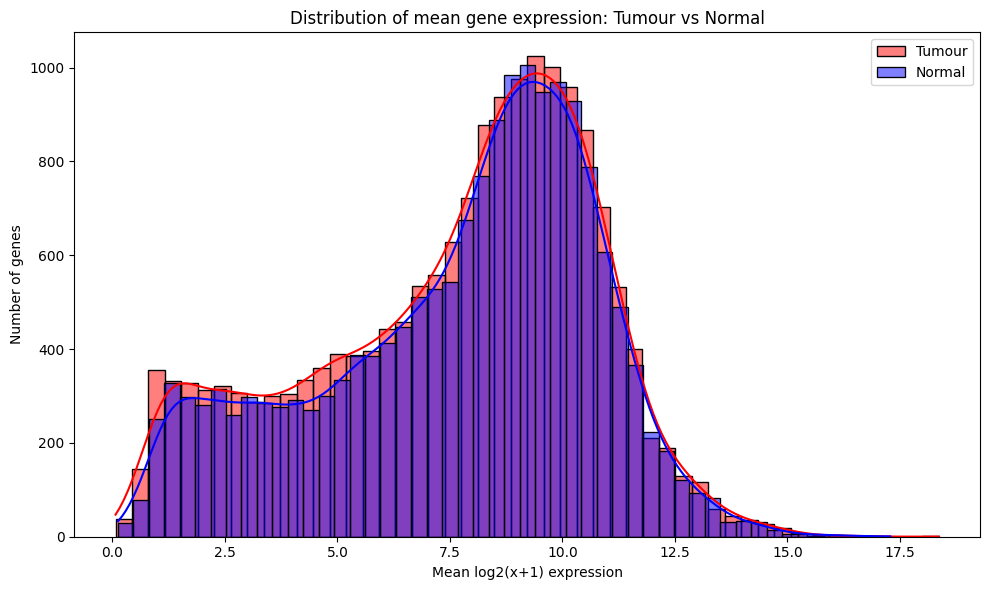

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a single axes object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot distribution of mean expression for tumour group
# bins=50 divides the data range into 50 equal-width intervals (bars)
# kde=True overlays a smooth kernel density estimation curve on the histogram
# alpha=0.5 sets 50% transparency so overlapping areas remain visible
# ax=ax directs the plot to our specific axes object instead of creating a new one
sns.histplot(tumour_mean, bins=50, kde=True, color='red', label='Tumour', alpha=0.5, ax=ax)
sns.histplot(normal_mean, bins=50, kde=True, color='blue', label='Normal', alpha=0.5, ax=ax)

# Add labels and title
ax.set_xlabel('Mean log2(x+1) expression')
ax.set_ylabel('Number of genes')
ax.set_title('Distribution of mean gene expression: Tumour vs Normal')
# legend() displays the labels defined in each histplot call
ax.legend()

# tight_layout() automatically adjusts spacing to prevent labels from being cut off
plt.tight_layout()
# show() renders and displays the figure
plt.show()

### 3.6.3: Distribution interpretation

The distributions of mean expression are highly similar between tumour and normal groups, with a main peak around 8–10 in log2 scale. Both distributions are bimodal: a first peak near 1–2 represents lowly expressed genes that passed the filter, and a second dominant peak around 9 represents the bulk of actively expressed genes. Neither distribution follows a normal curve, which provides a first indication that parametric methods assuming normality may not be appropriate. This will be further investigated at the per-gene level in the next section.

## **3.7: Per-gene visual distribution normality assessment**

The previous distribution plot (3.6.2) showed that the overall distribution of mean expression across genes is not normal. However, the Wilcoxon rank-sum (Mann-Whitney) test is applied gene by gene, comparing expression values across patients for each individual gene. It is therefore important to verify that these per-gene distributions are also non-normal.

To assess this, three genes will be selected to represent different expression levels (highly expressed, moderately expressed, lowly expressed). For each selected gene, a histogram and a Q-Q plot will be generated for the tumour group.

A visual approach was chosen over a formal normality test such as Shapiro-Wilk. With 493 tumour samples per gene, Shapiro-Wilk would have excessive statistical power and reject normality for almost 
every gene, even for minor deviations without practical impact on the choice of statistical test. A more quantitative alternative would have been to compute skewness and kurtosis for all 17,361 genes, but for this analysis a visual demonstration on three representative genes was preferred for clarity and lisibility. 
This visual check complements the theoretical justification provided by Li et al. (2022), which recommends the Wilcoxon rank-sum test for large-sample RNA-seq studies.

### 3.7.1: Gene selection for normality assessment

To select three representative genes at different expression levels (high, moderate, low), the summary statistics of mean tumour expression are first inspected. The quartiles (Q25, Q50, Q75) will guide the selection of genes at each expression level.
The tumour group is chosen for visual inspection because it contains 493 samples, providing a much more informative distribution shape than the normal group (52 samples). Moreover, the parametric alternative (t-test) would require both groups to be approximately normal, so demonstrating non-normality in the larger group is sufficient to justify the choice of a non-parametric test.


In [10]:
# Look at the distribution of mean expression to choose example genes
print("Tumour mean expression - summary:")
print(tumour_mean.describe())

Tumour mean expression - summary:
count    17361.000000
mean         7.588509
std          3.152864
min          0.071446
25%          5.425218
50%          8.312923
75%          9.933891
max         18.363804
dtype: float64


### 3.7.2: Gene selection criteria

The mean tumour expression ranges from 0.07 to 18.36 in log2 scale. The median (Q50) is 8.31 and the first quartile (Q25) is 5.43. Three genes will be selected to represent different expression levels. FOLH1 is kept as the highly expressed example, consistent with its role as positive control for the pipeline (Section 3.5.1). Two additional genes will be identified in the next step: one with mean expression close to the median (moderately expressed) and one close to Q25 (lowly expressed).


### 3.7.3: Identifying candidate genes at each expression level

FOLH1 is first checked to confirm it sits at the high end of the expression distribution. Then, genes with mean expression close to the median (Q50 ≈ 8.3) and to the first quartile (Q25 ≈ 5.4) are identified. A tolerance of 0.01 is used to find genes with expression values very close to these targets. Among the matches, genes encoding transmembrane or surface proteins are preferred, as they are more relevant to the RLT context of this analysis.

In [11]:
# FOLH1 is kept as the highly expressed example (positive control from Section 3.5.1)
# Verify its position in the overall expression distribution
folh1_idx = df_tumour[df_tumour['Hugo_Symbol'] == 'FOLH1'].index[0]
print(f"FOLH1 mean expression: {tumour_mean[folh1_idx]:.2f} (max in dataset: {tumour_mean.max():.2f})")

# Find genes with moderate expression (close to median, Q50 ≈ 8.3)
print("\nGenes near Q50 (moderate expression):")
print(df_tumour[abs(tumour_mean - 8.3) < 0.01]['Hugo_Symbol'])

# Find genes with low expression (close to Q25 ≈ 5.4)
print("\nGenes near Q25 (low expression):")
print(df_tumour[abs(tumour_mean - 5.4) < 0.01]['Hugo_Symbol'])

FOLH1 mean expression: 13.21 (max in dataset: 18.36)

Genes near Q50 (moderate expression):
333          ADCY1
444        AGTPBP1
574         ALKBH4
1139         ASXL2
1512         BICD1
1575          BOP1
1631        BTBD11
1891     C14orf179
2020      C17orf56
2508       C4orf10
2603      C6orf132
3153        CCDC52
3191       CCDC85B
3272        CCNYL1
3307         CD177
3430        CDCA7L
4153            CP
4281        CRYBG3
5440          EHD3
6243        FBXL12
6246        FBXL15
6627         FOXN2
7060           GLA
7612         HABP4
7642         HAUS2
7658         HBEGF
7923           HLF
8094          HSCB
8119          HSF4
9428         LATS1
10820          MET
11145        MRPL1
11242         MSI1
11430         MYL5
11816       NFATC4
12873     PAFAH1B2
12903        PAMR1
13554        PLCD3
13583      PLEKHA7
13767       POLR3D
13826       POU6F1
13941      PPP2R3A
13958       PPP4R2
14263        PSMB9
14827         RELB
14902        RGPD3
15388         RTN2
15687       SEC

### 3.7.4: Gene selection

From the results, three genes were selected to represent different expression levels: FOLH1 (highly expressed, positive control for the pipeline), CD177 (moderately expressed, close to Q50, cell surface marker), and TLR7 (lowly expressed, close to Q25, transmembrane receptor). This selection spans the upper three quartiles of the expression distribution and ensures that the normality assessment is representative of genes that will actually be tested in the ifferential expression analysis.

### 3.7.5: Histograms and Q-Q plots of selected genes

For each of the three selected genes (FOLH1, CD177, TLR7), two visualisations are generated for the tumour group: a histogram showing the distribution of expression values across the 493 tumour patients, and a Q-Q plot (quantile-quantile plot) comparing the empirical distribution to a theoretical normal distribution. 
In a Q-Q plot, points falling along the diagonal line indicate a normal distribution; deviations from the line indicate departures from normality. If the three genes show clear non-normality across different expression levels, this confirms that a non-parametric test (Wilcoxon rank-sum / Mann-Whitney) is the appropriate choice for the differential expression analysis.

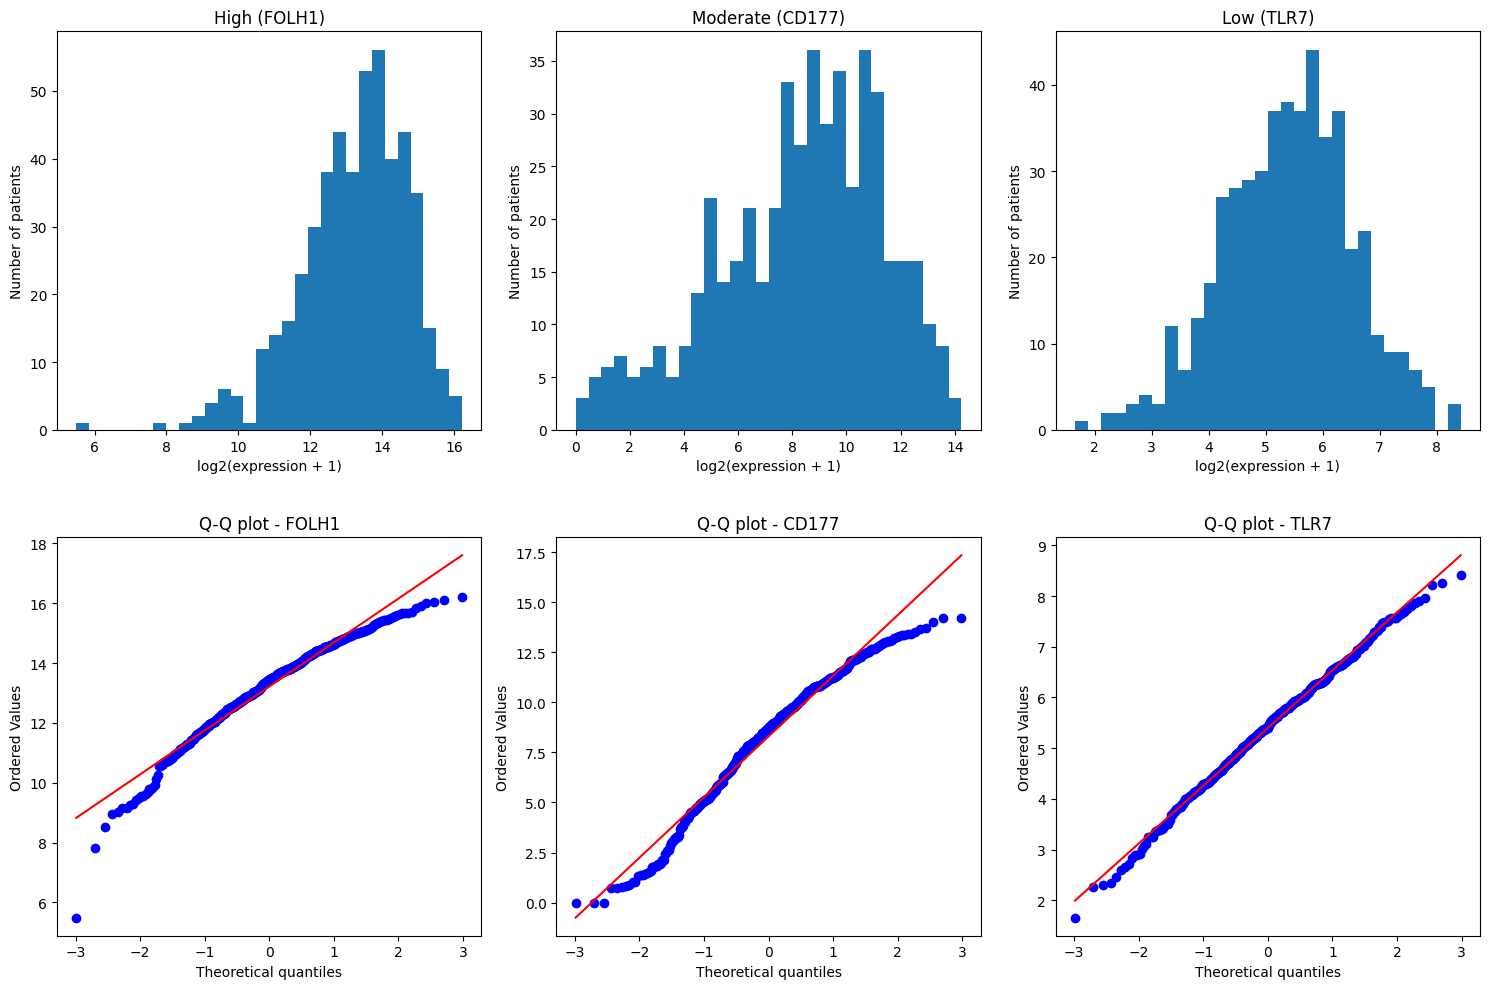

In [12]:
import matplotlib.pyplot as plt
from scipy import stats

# Define the 3 example genes
genes = ['FOLH1', 'CD177', 'TLR7']
labels = ['High (FOLH1)', 'Moderate (CD177)', 'Low (TLR7)']

# Create figure with 2 rows (histogram + Q-Q) x 3 columns (one per gene)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Loop through each gene: i = column index (0, 1, 2), gene = gene name
for i, gene in enumerate(genes):
    # Find the index of the gene in the dataframe
    gene_idx = df_tumour[df_tumour['Hugo_Symbol'] == gene].index[0]
    # Extract expression values as numpy array, remove NaN
    # Using loc (not iloc) because original index is preserved after filtering
    values = df_tumour.loc[gene_idx, df_tumour.columns[2:]].dropna().astype(float).values

    # Top row: histogram of expression distribution
    axes[0, i].hist(values, bins=30)
    axes[0, i].set_title(f'{labels[i]}')
    axes[0, i].set_xlabel('log2(expression + 1)')
    axes[0, i].set_ylabel('Number of patients')

    # Bottom row: Q-Q plot to compare with normal distribution
    # If points follow the diagonal line = normal distribution
    # If points deviate from the line = not normal
    stats.probplot(values, dist="norm", plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q plot - {gene}')

# Increase spacing between subplots to avoid overlapping text
plt.tight_layout(h_pad=3)
plt.show()

### 3.7.6: Per-gene visual normality assessment summary

The histograms and Q-Q plots confirm that the expression distributions of the three selected genes do not follow a normal distribution. None of the histograms show a symmetric bell-shaped curve, and in the Q-Q plots the data points deviate from the red line (which represents a theoretical normal distribution), particularly at the extremities. 
This non-normality is observed across all three expression levels (high, moderate, low), confirming that it is a general feature of RNA-seq data in this dataset and not limited to a specific expression range.  
This empirical observation, combined with the theoretical recommendation of Li et al. (2022) for large-sample RNA-seq studies, justifies the use of the Mann-Whitney U test for the differential expression analysis in the next section.

---

# **Section 4: Differential Expression Analysis**


## **4.1: Fold change calculation**

The fold change measures the difference in expression between tumour nd normal samples. Since the log2(x+1) transformation has already been applied, the fold change is calculated as a simple subtraction: log2FC = mean(tumour) − mean(normal). A log2FC of 2 corresponds to 2² = 4-fold higher expression in tumour, which is the threshold defined in Section 2.3 for biological significance.

A median-based fold change is also calculated because the per-gene distributions are not normal (as demonstrated in Section 3.6), the mean can be influenced 
by outliers, while the median is a more robust estimator. Comparing the two values acts as a check: if mean-based and median-based fold changes are similar, the signal is robust and homogeneous across patients; if they diverge substantially, the signal may be driven by a small subset of patients with extreme expression values.

FOLH1 is again used as a positive control to verify that the fold change calculation produces a value consistent with its known overexpression in prostate cancer.

In [13]:
# Calculate mean-based log2 fold change
log2FC_mean = tumour_mean - normal_mean

# Calculate median-based log2 fold change for robustness check
log2FC_median = tumour_median - normal_median

# Verify with FOLH1 (positive control)
folh1_idx = df_tumour[df_tumour['Hugo_Symbol'] == 'FOLH1'].index[0]
print(f"FOLH1 - log2FC mean: {log2FC_mean[folh1_idx]:.2f}")
print(f"FOLH1 - log2FC median: {log2FC_median[folh1_idx]:.2f}")

FOLH1 - log2FC mean: 2.63
FOLH1 - log2FC median: 1.96


### 4.1.2: Fold change interpretation (FOLH1 positive control)

FOLH1 log2FC mean (2.63) is above the threshold of 2, corresponding to approximately 6.2-fold higher expression in tumour (2^2.63 ≈ 6.2). The median-based log2FC (1.96) is slightly below the threshold, corresponding to approximately 3.9-fold higher expression (2^1.96 ≈ 3.9). The difference between the two values suggests that a small subset of patients with very high FOLH1 expression pulls the mean slightly upward, but the signal remains globally robust since both values point to a strong overexpression in tumour.

For the differential expression analysis, the mean-based fold change will be used as the primary criterion, consistent with standard practice in transcriptomics and with the rest of
the pipeline (mean expression was used for filtering and descriptive statistics). The median-based fold change will be retained as a robustness check.

## **4.2: Statistical significance (Mann-Whitney + BH correction)**

The Mann-Whitney U test is applied to each of the 17,361 genes to compare expression between tumour and normal samples. Mann-Whitney is a non-parametric test, meaning it does not assume any specific distribution of the data. It was validated by Li et al. (2022, Genome Biology) as offering the best False Discovery Rate (FDR) control and statistical power for large-sample RNA-seq studies. Each test produces a p-value indicating whether the expression difference for a given gene is statistically significant.

However, testing 17,361 genes simultaneously at p < 0.05 would produce approximately 868 false positives by chance alone (17,361 × 0.05 ≈ 868). A correction for multiple testing is 
therefore essential. Benjamini-Hochberg (BH) correction is applied to control the FDR: after correction, among all genes declared significant, at most 5% are expected to be false positives. BH is the standard correction method in transcriptomics (Benjamini & Hochberg, 1995) and is preferred over more conservative alternatives like Bonferroni, which would reject too many true positives in a dataset of this size.

The final filter combines two criteria: |log2FC| > 2 (at least 4-fold difference in expression) AND adjusted p-value < 0.05. Both are necessary: a gene can be statistically significant with a very small fold change (not biologically relevant), or have a large fold change but not be statistically significant (high variability leads to a non-significant p-value). Only genes that pass both filters are retained as candidates.

### 4.2.1: Mann-Whitney U test

The Mann-Whitney U test is applied gene by gene through a loop, producing one p-value per gene.

In [14]:
from scipy.stats import mannwhitneyu

# Empty list to store p-values, one per gene
pvalues = []

# Loop through each gene (each row in the dataframe)
for idx in df_tumour.index:
    # Extract expression values for this gene across all tumour patients (as numpy float array)
    tumour_values = df_tumour.loc[idx, df_tumour.columns[2:]].dropna().astype(float).values
    # Extract expression values for this gene across all normal patients (as numpy float array)
    normal_values = df_normal.loc[idx, df_normal.columns[2:]].dropna().astype(float).values
    # Run Mann-Whitney U test: compares tumour vs normal for this gene
    # _ = U statistic (not needed), pvalue = probability that the difference is due to chance
    _, pvalue = mannwhitneyu(tumour_values, normal_values)
    # Add this gene's p-value to the list
    pvalues.append(pvalue)

# Convert list to numpy array for vectorized operations
pvalues = np.array(pvalues)

print("Number of p-values:", len(pvalues))
print(f"Genes with raw p-value < 0.05: {(pvalues < 0.05).sum()}")

Number of p-values: 17361
Genes with raw p-value < 0.05: 12343


#### 4.2.1.1: Mann-Whitney results

The Mann-Whitney U test was successfully applied to all 17,361 genes, producing one p-value per gene. Before any correction, 12,343 genes (71%) have a raw p-value below 0.05. This high proportion reflects two combined effects: the large sample size gives the test considerable statistical power to detect even very small differences, and the lack of correction inflates the false positive rate across 17,361 simultaneous tests. Without correction, many of these p-values would correspond to statistically detectable but biologically negligible differences. The Benjamini-Hochberg procedure applied in the next step will control the False Discovery Rate and combined with the |log2FC| > 2 filter, it will return a more realistic list of candidates with both statistical and biological significance.


### 4.2.2: Multiple testing Benjamini-Hochberg correction

The Benjamini-Hochberg (BH) correction is applied to the 17,361 raw p-values to control the False Discovery Rate at 5%. The number of significant genes is compared before and after correction to illustrate the impact of controlling for multiple testing.

In [15]:
# Import the multipletests function from statsmodels to correct p-values for multiple testing
from statsmodels.stats.multitest import multipletests

# multipletests returns 4 values:
# 1st: reject (boolean)
# 2nd: corrected p-values (the ones we want)
# 3rd: alphacSidak (corrected alpha for Sidak method)
# 4th: alphacBonf (corrected alpha for Bonferroni method)
# _ to discard values we don't need
# method='fdr_bh' specifies the Benjamini-Hochberg FDR correction
_, pvalues_bh, _, _ = multipletests(pvalues, method='fdr_bh')

# Count significant genes before correction
# sum(p < 0.05 for p in pvalues) is a generator expression: iterates through each p-value,
# returns True/False, and sum() counts the True values
print("Significant genes (no correction, p < 0.05):", sum(p < 0.05 for p in pvalues))

# Count significant genes after BH correction
# pvalues_bh is a numpy array, so (pvalues_bh < 0.05) returns a boolean numpy array
# sum() on a boolean numpy array counts the True values directly
print("Significant genes (BH, adj.p < 0.05):", sum(pvalues_bh < 0.05))

Significant genes (no correction, p < 0.05): 12343
Significant genes (BH, adj.p < 0.05): 11975


#### 4.2.2.1: Interpretation of multiple testing correction

After Benjamini-Hochberg correction, 11,975 genes remain significant (adjusted p < 0.05), compared to 12,343 genes before correction. The reduction is modest because the Mann-Whitney U test, combined with a very large sample size (493 vs 52), produces many p-values that are already very small and therefore remain significant after 
correction.  
However, statistical significance alone is not sufficient to identify biologically relevant candidates: this is why the final filter also requires |log2FC| > 2, to retain only genes with a meaningful magnitude of difference between tumour and normal tissue, consistent with the thresholds defined in Section 2.3.

### 4.2.3: Sensitivity analysis: Wilcoxon signed-rank test on 52 paired samples

As demonstrated in Section 3.5, all 52 normal samples have a matched tumour sample from the same patient. The Mann-Whitney U test applied in Section 4.2.1 treats all samples as independent, which violates the independence assumption for these 52 paired observations. To verify that the statistical results are robust to this paired structure, a Wilcoxon signed-rank test is applied on the 52 paired samples only. This test compares, for each gene, the tumour and normal expression values within the same patient. The same BH correction is applied. The goal is not to replace the primary analysis but to check whether the p-values are consistent under a paired design.

In [16]:
from scipy.stats import wilcoxon

# Identify the 52 normal sample columns
normal_cols = df_normal.columns[2:]

# Build matching tumour column names by replacing -11 suffix with -01
paired_tumour_cols = [col.replace('-11', '-01') for col in normal_cols]

# Verify that all 52 matched tumour columns exist in df_tumour
matched = [col for col in paired_tumour_cols if col in df_tumour.columns]
print(f"Paired samples verified: {len(matched)}/52")

# Extract expression matrices for the 52 pairs only
# Rows = genes, Columns = 52 patients, same patient order in both matrices
paired_normal_expr = df_normal[normal_cols].values
paired_tumour_expr = df_tumour[matched].values

# Run Wilcoxon signed-rank test for each gene
pvalues_paired = []
for i in range(paired_tumour_expr.shape[0]):
    tumour_vals = paired_tumour_expr[i, :]
    normal_vals = paired_normal_expr[i, :]
    # Wilcoxon requires at least one non-zero difference between pairs
    diff = tumour_vals - normal_vals
    if np.all(diff == 0):
        pvalues_paired.append(1.0)
    else:
        try:
            _, pval = wilcoxon(tumour_vals, normal_vals)
            pvalues_paired.append(pval)
        except ValueError:
            pvalues_paired.append(1.0)

pvalues_paired = np.array(pvalues_paired)

# Apply Benjamini-Hochberg correction
_, pvalues_paired_bh, _, _ = multipletests(pvalues_paired, method='fdr_bh')

# Compare significance between the two tests
mw_sig = sum(pvalues_bh < 0.05)
wx_sig = sum(pvalues_paired_bh < 0.05)
both_sig = sum((pvalues_bh < 0.05) & (pvalues_paired_bh < 0.05))

print(f"\nSignificant genes (Mann-Whitney, BH adj.p < 0.05): {mw_sig}")
print(f"Significant genes (Wilcoxon paired, BH adj.p < 0.05): {wx_sig}")
print(f"Significant in both: {both_sig}")

Paired samples verified: 52/52

Significant genes (Mann-Whitney, BH adj.p < 0.05): 11975
Significant genes (Wilcoxon paired, BH adj.p < 0.05): 10696
Significant in both: 9280


#### 4.2.3.1: Sensitivity analysis results

The Wilcoxon signed-rank test identifies 10,696 significant genes (BH adj.p < 0.05), compared to 11,975 for the Mann-Whitney U test. 9,280 genes are significant in both tests (87% of Wilcoxon results, 77% of Mann-Whitney results). The reduction is expected given the lower statistical power of 52 pairs vs 493+52 samples. The high overlap confirms that the statistical signal is largely robust to the paired data structure. The key candidates are verified individually in the next step.

In [49]:
# Verify FOLH1 (positive control) in both tests
folh1_idx = df_tumour[df_tumour['Hugo_Symbol'] == 'FOLH1'].index[0]
folh1_pos = df_tumour.index.get_loc(folh1_idx)

print("--- FOLH1 positive control validation ---")
print(f"Mann-Whitney adj.p = {pvalues_bh[folh1_pos]:.2e}")
print(f"Wilcoxon paired adj.p = {pvalues_paired_bh[folh1_pos]:.2e}")
print(f"log2FC = {log2FC_mean.iloc[folh1_pos]:.2f}")

--- FOLH1 positive control validation ---
Mann-Whitney adj.p = 6.57e-14
Wilcoxon paired adj.p = 1.80e-07
log2FC = 2.63


#### 4.2.3.2: FOLH1 positive control validation

FOLH1 is highly significant in both tests (Mann-Whitney adj.p = 6.57e-14, Wilcoxon paired adj.p = 1.80e-07), confirming that its overexpression is a consistent within-patient signal. The higher p-value in the Wilcoxon test reflects the reduced sample size (52 pairs vs 493+52 samples), not a weaker signal. This validates the robustness of the primary analysis for the known RLT benchmark target. The final candidates identified in Section 10 will be verified against the paired test at that stage.

## **4.3: Differentially Expressed Genes (DEGs) identification: combining p-value and fold change**

At this stage, two independent criteria have been computed for each gene: an adjusted p-value (from the Mann-Whitney U test corrected with Benjamini-Hochberg) and a log2 fold change (from Section 4.1). Each criterion captures a different aspect of differential expression.

The adjusted p-value reflects **statistical significance**: how confident we are that the observed difference is not due to chance. A gene with adjusted p < 0.05 means that, after controlling for multiple testing, the probability of observing this difference by chance is less than 5%.

The log2 fold change reflects **biological significance**: how large the expression difference is in magnitude. A gene with |log2FC| > 2 means the expression is at least 4-fold higher or lower in tumour compared to normal tissue.

Both criteria are necessary to identify meaningful candidates. A gene can be statistically significant with a very small fold change (not biologically relevant), or have a large fold change without reaching statistical significance (high variability between patients). Only genes that pass both filters simultaneously are retained as DEGs and will be considered as potential RLT target candidates in the next steps.

In [17]:
# Apply combined filter: biological significance AND statistical significance
final_filter = (abs(log2FC_mean) > 2) & (pvalues_bh < 0.05)

# Count differentially expressed genes (DEGs)
print("Differentially Expressed Genes (|log2FC| > 2 and BH adj.p < 0.05):", sum(final_filter))

Differentially Expressed Genes (|log2FC| > 2 and BH adj.p < 0.05): 311


### 4.3.1: Interpretation of identified DEGs

311 differentially expressed genes were identified using the combined filter (|log2FC| > 2 and BH adjusted p < 0.05). For comparison, He et al. (2022) identified 853 DEGs on the same TCGA cohort. This difference is expected and reflects several methodological choices.

First, He et al. applied DESeq2 on raw counts retrieved from GDC, which requires controlled access. This analysis instead uses Mann-Whitney U on pre-normalized RSEM data from cBioPortal which has less statistical power but is more conservative and robust to outliers. As demonstrated by Li et al. (2022), Mann-Whitney offers better FDR control on large-sample RNA-seq datasets, which is an acceptable trade-off for this analysis.

Second, the pre-processing in Section 3.3 removed 3,170 lowly expressed genes (mean log2 expression ≤ 1 in both groups), which may have excluded some candidates before testing.

Obtaining fewer DEGs is not a weakness of this pipeline: a more stringent approach reduces false positives and ensures that the 
retained candidates represent strong, robust signals. This is particularly relevant in the context of RLT target discovery, where only genes with substantial and reliable overexpression are worth pursuing for further validation.

## **4.4: Separating overexpressed and underexpressed DEGs**

The 311 DEGs identified in the previous step are now split into two groups based on the direction of the fold change. Genes overexpressed in tumour (log2FC > 2) are the potential RLT target candidates, as RLT requires the target to be present on tumour cells at higher levels than on normal tissue.  
Genes underexpressed in tumour (log2FC < −2) are not relevant for 
RLT target discovery, but they are still counted here as check on the pipeline and will appear on the left side of the volcano plot in the next section.  
FOLH1 is also checked as a positive control to confirm that it is correctly classified as overexpressed in tumour.

In [18]:
# Overexpressed in tumour (log2FC > 2): potential RLT candidates
final_overexpressed = (log2FC_mean > 2) & (pvalues_bh < 0.05)

# Underexpressed in tumour (log2FC < -2): not relevant for RLT
final_underexpressed = (log2FC_mean < -2) & (pvalues_bh < 0.05)

# Count DEGs in each direction
# sum() counts the number of True values in each filter
print("DEGs overexpressed in tumour:", sum(final_overexpressed))
print("DEGs underexpressed in tumour:", sum(final_underexpressed))

# Verify with FOLH1 (positive control)
folh1_idx = df_tumour[df_tumour['Hugo_Symbol'] == 'FOLH1'].index[0]
print("\nFOLH1 is overexpressed:", final_overexpressed[folh1_idx])

DEGs overexpressed in tumour: 95
DEGs underexpressed in tumour: 216

FOLH1 is overexpressed: True


### 4.4.1: Distribution and biological relevance of the two groups

Among the 311 DEGs identified by the combined filter, 95 are overexpressed in tumour (log2FC > 2) and 216 are underexpressed (log2FC < −2). This imbalance suggests that prostate tumourigenesis may involve more gene silencing than gene activation.  
FOLH1 is correctly classified as overexpressed, confirming that the pipeline identifies the validated PSMA target as expected.


Only the 95 overexpressed genes are relevant as potential RLT targets, since RLT requires a protein that is more abundant on tumour cells than on normal tissue. These 95 genes will be carried forward to the target prioritisation steps in Sections 7, 8, 9 (surface protein filtering with UniProt, off-target toxicity control with GTEx, and protein-level validation with Human Protein Atlas).

---

# **Section 5: Visualization**  



## **5.1: Volcano plot preparation**

Before plotting, two quantities are computed: the -log10 of the adjusted p-values (for the y-axis) and a color assignment for each gene based on its status (overexpressed in red, underexpressed in blue, not significant in grey).

In [19]:
# Calculate -log10 of BH-corrected p-values for volcano plot y-axis
# np.log10() computes the base-10 logarithm, the minus sign inverts the scale
# so that smaller p-values (more significant) produce larger values
neg_log10_pvalues = -np.log10(pvalues_bh)

# Assign a color to each gene based on differential expression status
# Empty list that will be filled with one color string per gene
colors = []
# range(len(log2FC_mean)) generates indices from 0 to number of genes - 1
for i in range(len(log2FC_mean)):
    # .iloc[i] accesses the i-th element by position (not by label)
    # final_overexpressed is a boolean Series, so .iloc[i] returns True or False
    if final_overexpressed.iloc[i]:
        colors.append('red')
    elif final_underexpressed.iloc[i]:
        colors.append('blue')
    else:
        colors.append('grey')

# Verify the color assignment by counting each category
# list.count() counts the number of occurrences of a value in the list
print("Data prepared for volcano plot")
print("Red (overexpressed):", colors.count('red'))
print("Blue (underexpressed):", colors.count('blue'))
print("Grey (not significant):", colors.count('grey'))

Data prepared for volcano plot
Red (overexpressed): 95
Blue (underexpressed): 216
Grey (not significant): 17050


### 5.1.1: Data preparation verification

95 genes are classified as overexpressed (red), 216 as underexpressed (blue), and 17,050 as not significant (grey). 
The total (95 + 216 + 17,050 = 17,361) matches the number of genes after filtering in Section 3.3, confirming that the classification is correct and that no gene has been lost or duplicated.

## **5.2: Volcano plot visualisation**

The volcano plot displays log2 fold change on the x-axis and statistical significance (-log10 adjusted p-value) on the y-axis. Red points represent overexpressed DEGs (log2FC > 2, adjusted p < 0.05), blue points represent underexpressed DEGs, and grey points are not significant. Dashed lines mark the thresholds used in the analysis (|log2FC| = 2 and adjusted p = 0.05).  
FOLH1 is highlighted in green as a positive control and should appear in the top-right quadrant.

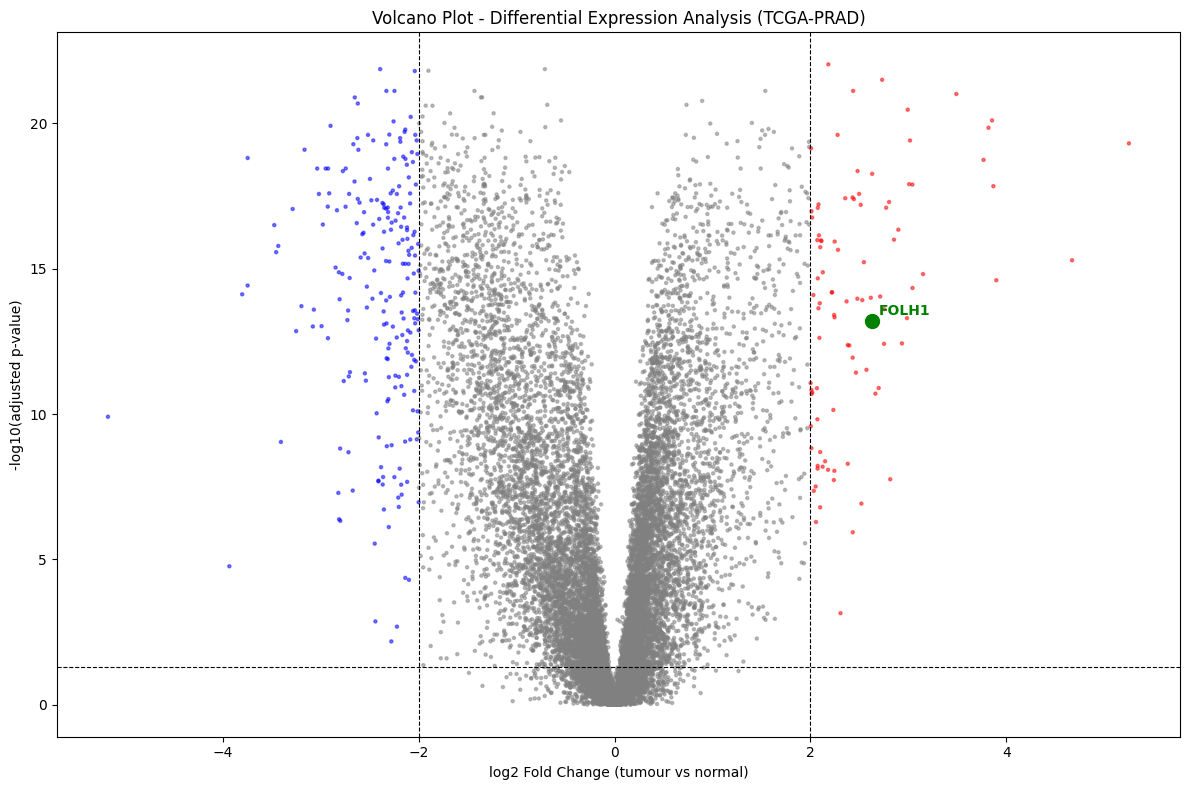

In [20]:
# Create volcano plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all genes (log2FC_mean = x-coordinates, neg_log10_pvalues = y-coordinates, c=colors passes the pre-computed list of colors (one per gene))
ax.scatter(log2FC_mean, neg_log10_pvalues, c=colors, alpha=0.5, s=5)

# Add threshold lines (dashed black lines)
# Vertical lines at log2FC = -2 and +2
ax.axvline(x=2, color='black', linestyle='--', linewidth=0.8)
ax.axvline(x=-2, color='black', linestyle='--', linewidth=0.8)

# Horizontal line at adj.p = 0.05 (equivalent to -log10(0.05) = 1.3)
# -np.log10(0.05) converts the p-value threshold to the y-axis scale
ax.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=0.8)

# Highlight FOLH1 (positive control) in green
# Find the dataframe row index where Hugo_Symbol equals 'FOLH1'
folh1_idx = df_tumour[df_tumour['Hugo_Symbol'] == 'FOLH1'].index[0]
# get_loc() converts the label-based index into a positional index
# This is needed because neg_log10_pvalues is a numpy array (positional), 
# while log2FC_mean is a pandas Series (label-based)
folh1_pos = log2FC_mean.index.get_loc(folh1_idx)
# Plot a single larger green point on top of the existing scatter
# s=100 makes it much bigger, zorder=5 ensures it's drawn above other points
ax.scatter(log2FC_mean[folh1_idx], neg_log10_pvalues[folh1_pos], color='green', s=100, zorder=5)
# annotate() adds a text label near the point
# First argument is the label text, second is the (x, y) point to annotate
# xytext=(5, 5) offsets the text 5 pixels right and 5 pixels up from the point
# textcoords='offset points' specifies that xytext is in pixel offsets, not data coordinates
ax.annotate('FOLH1', (log2FC_mean[folh1_idx], neg_log10_pvalues[folh1_pos]),fontsize=10, fontweight='bold', color='green',xytext=(5, 5), textcoords='offset points')

# Add axis labels and title
ax.set_xlabel('log2 Fold Change (tumour vs normal)')
ax.set_ylabel('-log10(adjusted p-value)')
ax.set_title('Volcano Plot - Differential Expression Analysis (TCGA-PRAD)')

# tight_layout() automatically adjusts spacing to prevent labels from being cut off
plt.tight_layout()
plt.show()

## **5.3: Volcano plot interpretation**

The volcano plot shows the bulk of non-significant genes (grey) clustered around log2FC = 0, spreading symmetrically as fold change increases. The dashed lines mark the analytical thresholds (**|log2FC| = 2 and adjusted p = 0.05**); only points in the upper-left and upper-right regions pass both filters.

The 95 overexpressed DEGs (red, upper-right) are well separated from the bulk of non-significant genes, with most showing very high statistical significance (very low adjusted p-values) and fold changes ranging from 2 to over 5. The 216 underexpressed DEGs (blue, upper-left) form a denser cluster, consistent with the imbalance observed in Section 4.4.1.

FOLH1 is correctly positioned in the upper-right region, with a log2FC of 2.63 and a high statistical significance, confirming that the pipeline successfully identifies the validated PSMA target. This serves as a positive control.  

**The 95 red points constitute the final list of candidate genes that will be carried forward to the target prioritisation steps.**

---

# **Section 6: Biological interpretation**  

After identifying 95 genes overexpressed in tumour through the differential expression analysis, the next step is to interpret these results from a biological perspective and prioritise the most promising candidates for further validation as RLT targets. This section ranks the candidates by fold change, examines the top hits, and assesses their biological relevance in the context of prostate cancer.

## **6.1: Top candidate extraction and ranking**

The 95 overexpressed DEGs are extracted into a dedicated dataframe containing their gene symbol, mean and median log2 fold change, adjusted p-value, and the percentage of tumour samples in which they are expressed. The list is sorted by mean log2 fold change in descending order, and the top 20 candidates are displayed for readability.

In [21]:
# Create a new dataframe containing only the 95 overexpressed genes
# pd.DataFrame() builds a new dataframe from a dictionary
# Each key becomes a column name, each value is the column data
results_overexpressed = pd.DataFrame({
    # df_tumour.loc[boolean_mask, 'Hugo_Symbol'] selects the Hugo_Symbol column for rows where the mask is True
    # .values converts the pandas Series to a numpy array
    'Hugo_Symbol': df_tumour.loc[final_overexpressed, 'Hugo_Symbol'].values,
    # log2FC_mean[final_overexpressed] applies boolean indexing to keep only the overexpressed genes
    'log2FC_mean': log2FC_mean[final_overexpressed].values,
    'log2FC_median': log2FC_median[final_overexpressed].values,
    # pvalues_bh is a numpy array, so boolean indexing works directly without .values
    'adj_pvalue_BH': pvalues_bh[final_overexpressed],
    'tumour_pct_expressed': tumour_pct_expressed[final_overexpressed].values
})

# Sort the dataframe by log2FC_mean column
# ascending=False sorts from highest to lowest
# This returns a new dataframe and reassigns it to the same variable
results_overexpressed = results_overexpressed.sort_values('log2FC_mean', ascending=False)

# Display the top 20 rows of the sorted dataframe
# .head(20) returns the first 20 rows
# .to_string(index=False) converts to a clean string without the default pandas row numbers
print("Top 20 overexpressed genes (sorted by log2FC mean):")
print(results_overexpressed.head(20).to_string(index=False))

Top 20 overexpressed genes (sorted by log2FC mean):
 Hugo_Symbol  log2FC_mean  log2FC_median  adj_pvalue_BH  tumour_pct_expressed
        DLX1     5.253774       6.592005   4.902087e-20             99.797160
        PCA3     4.672714       5.923504   5.154421e-16            100.000000
       TDRD1     3.898810       5.245524   2.504924e-15             99.594320
        ZIC2     3.868641       5.119900   1.454385e-18             96.754564
     SLC45A2     3.854834       4.239497   7.960204e-21             99.391481
       HOXC6     3.818573       4.566810   1.422446e-20            100.000000
        DLX2     3.768126       4.460845   1.812237e-19             97.971602
      NKX2-3     3.490303       4.144190   9.792987e-22             97.363083
     COL10A1     3.150173       3.850690   1.535865e-15             99.594320
        ZIC5     3.042854       3.964464   4.620683e-15             87.018256
       HOXC4     3.041695       3.276321   1.280237e-18             99.594320
       AMACR

### 6.1.1: Interpretation of top overexpressed genes

The top 20 overexpressed genes show strong differential expression, with mean-based and median-based fold changes that are close, indicating that the signal is not driven by outliers. All 20 genes are expressed in more than 87% of tumour samples.

DLX1 has the highest fold change (log2FC = 5.25). FOLH1B, a paralogue of FOLH1/PSMA, also appears in the list.FOLH1 itself does not appear in the top 20: its log2FC of 2.63 
ranks it in the lower range of the 95 overexpressed DEGs.

The 95 overexpressed genes will now be filtered using UniProt (cell surface membrane protein annotation), GTEx (vital tissue expression control), and Human Protein Atlas(protein-level IHC validation).

### 6.1.2: FOLH1 ranking among overexpressed candidates

The previous interpretation noted that FOLH1 does not appear in he top 20 candidates. Its exact rank among the 95 overexpressed genes is now computed to quantify this observation.

In [22]:
# Reset index to 0, 1, 2... so that row position = rank
# drop=True discards the old index instead of adding it as a column
results_ranked = results_overexpressed.reset_index(drop=True)

# Find the row number where Hugo_Symbol equals 'FOLH1'
# .index[0] returns the first matching row number
# +1 because Python counts from 0 but ranking starts at 1
folh1_rank = results_ranked[results_ranked['Hugo_Symbol'] == 'FOLH1'].index[0] + 1

# Display FOLH1 rank and its full row of statistics
# to_string(index=False) prints without the pandas index number
print(f"FOLH1 rank among 95 overexpressed genes: {folh1_rank}/95")
print(results_ranked[results_ranked['Hugo_Symbol'] == 'FOLH1'].to_string(index=False))

FOLH1 rank among 95 overexpressed genes: 29/95
Hugo_Symbol  log2FC_mean  log2FC_median  adj_pvalue_BH  tumour_pct_expressed
      FOLH1     2.626037       1.962277   6.570506e-14                 100.0


### 6.1.3: Interpretation of FOLH1 ranking

FOLH1 ranks 29th out of 95 overexpressed genes. Its log2FC of 2.63 places it in the lower range of the differentially expressed genes, but it is still detected by the pipeline with a highly significant adjusted p-value (6.57e-14) and is expressed in 100% of tumour samples, validating the workflow.



## **6.2: Filtering for protein-coding genes**

The 95 overexpressed genes were identified from RNA-seq data, which measures all transcribed genes regardless of whether they code for a protein or not. RLT requires a surface protein for the radioligand to bind, so non-coding RNAs (such as lncRNAs, pseudogenes, miRNAs) cannot be RLT targets even if they are strongly overexpressed at the transcript level.

To remove these non-coding entries before the surface protein filtering step, the gene biotype of each candidate is retrieved from the Ensembl REST API. Only genes annotated as `protein_coding` will be carried forward to Section 7 (UniProt). The biotype information is also stored as a new column in the dataframe for traceability, allowing the composition of the overexpressed gene list to be analysed (number of protein_coding vs lncRNA vs other categories).

### 6.2.1: Querying Ensembl for gene biotype

The Ensembl REST API is used to retrieve the biotype of each of the 95 overexpressed genes. The query is performed gene by gene in a loop, with a short delay between requests to avoid overloading the server. Genes not found in Ensembl are marked as `'unknown'` for traceability rather than being silently dropped.

In [23]:
# Import libraries needed for HTTP requests, URL encoding, and timing
import urllib.request
import urllib.parse
import json
import time

# Get the list of 95 gene names from the overexpressed results dataframe
gene_list = results_overexpressed['Hugo_Symbol'].tolist()

# Empty list that will store one dictionary per gene with its biotype
ensembl_results = []

# Loop through each gene with its index for progress tracking
for i, gene in enumerate(gene_list):
    # Build the Ensembl REST API URL for the lookup/symbol endpoint
    # urllib.parse.quote() encodes special characters in the gene name (none expected here, but safer)
    url = f'https://rest.ensembl.org/lookup/symbol/homo_sapiens/{urllib.parse.quote(gene)}?expand=0'

    try:
        # Create the HTTP request object
        req = urllib.request.Request(url)
        # Add the Accept header to request a JSON response (Ensembl supports JSON, XML, etc.)
        req.add_header('Accept', 'application/json')
        # Send the request with a 10-second timeout to avoid hanging
        response = urllib.request.urlopen(req, timeout=10)
        # Read the response bytes and decode to text
        data = response.read().decode('utf-8')
        # json.loads() parses the JSON string into a Python dictionary
        result = json.loads(data)
        # Extract the biotype field from the dictionary
        # .get('biotype', 'unknown') returns 'unknown' if the key is missing
        biotype = result.get('biotype', 'unknown')
    except Exception:
        # If the request fails (network error, gene not found, HTTP 404), mark as unknown
        biotype = 'unknown'

    # Append a dictionary with gene name and biotype to the results list
    ensembl_results.append({
        'Hugo_Symbol': gene,
        'gene_biotype': biotype
    })

    # Wait 0.2 seconds between requests to avoid overloading the Ensembl server
    # Ensembl tolerates higher rates than UniProt, so 0.2s is enough
    time.sleep(0.2)

    # Print progress every 10 genes
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(gene_list)} genes...")

# Final message when the loop is complete
print(f"Done: {len(ensembl_results)} genes queried")

# Convert the list of dictionaries into a pandas DataFrame for easy manipulation
df_ensembl = pd.DataFrame(ensembl_results)

Processed 10/95 genes...
Processed 20/95 genes...
Processed 30/95 genes...
Processed 40/95 genes...
Processed 50/95 genes...
Processed 60/95 genes...
Processed 70/95 genes...
Processed 80/95 genes...
Processed 90/95 genes...
Done: 95 genes queried


### 6.2.1.1: Ensembl query completed

The 95 overexpressed genes have been successfully queried and their gene biotypes stored in the dataframe `df_ensembl`. The next step verifies the distribution of biotypes before applying the protein-coding filter.

### 6.2.2: Biotype quality check

Before filtering, the distribution of biotypes among the 95 overexpressed genes is inspected to provide a transparent overview of the gene composition (number of protein-coding 
genes, non-coding RNAs, pseudogenes, etc.).

In [24]:
# Display the count of each unique biotype value in the gene_biotype column
# .value_counts() returns a Series with biotype categories sorted by frequency (descending)
print("Biotype distribution among the 95 overexpressed genes:")
print(df_ensembl['gene_biotype'].value_counts())

Biotype distribution among the 95 overexpressed genes:
gene_biotype
protein_coding                        84
lncRNA                                 5
unknown                                5
transcribed_unprocessed_pseudogene     1
Name: count, dtype: int64


### 6.2.2.1: Biotype distribution interpretation

Among the 95 overexpressed genes, 84 are protein-coding, 5 are lncRNAs, 1 is a transcribed unprocessed pseudogene, and 5 were not found in Ensembl (marked as `unknown`). The 5 lncRNAs and 1 pseudogene will be excluded in the next filtering step since they cannot produce a surface protein for the radioligand to bind. 
The 5 unknown genes will be kept in the analysis, as their absence from Ensembl may reflect a naming mismatch rather than a confirmed non-coding status. They will be evaluated further in the downstream filtering steps (UniProt in Section 7, HPA in Section 9).

### 6.2.3: Filtering protein-coding genes

The overexpressed candidates are filtered to exclude entries that cannot produce a surface protein: 5 lncRNAs and 1 pseudogene are removed based on the Ensembl biotype annotation. The 5 genes marked as `unknown` (not found in Ensembl) are kept in the analysis, since their absence from Ensembl may be due to a name mismatch rather than a confirmed non-coding status. They will be evaluated further in the downstream UniProt filtering and HPA validation steps. The resulting dataframe `results_protein_coding` contains **89 candidates** (84 protein-coding + 5 unknown) and will be used as input for Section 7.

In [25]:
# Merge results_overexpressed with df_ensembl to add the gene_biotype column
# on='Hugo_Symbol' joins the two dataframes on the common gene name column
# how='left' keeps all rows from results_overexpressed (no gene is lost at this step)
results_with_biotype = pd.merge(
    results_overexpressed,
    df_ensembl,
    on='Hugo_Symbol',
    how='left'
)

# Filter to keep only protein_coding genes OR unknown genes
# | is the element-wise OR operator
# The condition keeps rows where biotype is 'protein_coding' OR 'unknown'
# Non-coding entries (lncRNA, pseudogene) are excluded
biotype_filter = (
    (results_with_biotype['gene_biotype'] == 'protein_coding') |
    (results_with_biotype['gene_biotype'] == 'unknown')
)

# Apply the filter to create the new dataframe
results_protein_coding = results_with_biotype[biotype_filter]

# Display the result
# len() returns the number of rows in the filtered dataframe
print(f"Candidates after biotype filtering: {len(results_protein_coding)}/95")
# .value_counts() confirms the biotype composition of the filtered dataframe
print("\nBiotype composition:")
print(results_protein_coding['gene_biotype'].value_counts())

Candidates after biotype filtering: 89/95

Biotype composition:
gene_biotype
protein_coding    84
unknown            5
Name: count, dtype: int64


### 6.2.3.1: Filtering results

The filtering confirms that 89 candidates are retained in the new dataframe `results_protein_coding`, which will be used as input for Section 7.

# **Section 7: RLT Target Prioritisation**

## **7.1: Filtering candidates by RLT-relevant subcellular localisation with UniProt**

Among the 89 protein-coding genes (section 6.2) identified, only those encoding transmembrane or cell surface proteins are relevant for RLT, since the radioligand must bind a target accessible from the bloodstream. UniProt, the reference database for protein annotation, provides subcellular localisation data for each protein. Rather than searching 89 genes manually, the UniProt REST API is used to retrieve this information programmatically.

Two fields are retrieved from UniProt for each gene: the subcellular location annotation and the transmembrane domain annotation. A protein is retained as a potential RLT target if its annotation contains any of the following terms: "Cell membrane", "Cell surface", or if a transmembrane domain is annotated. Proteins annotated exclusively as intracellular (e.g. Cytoplasm, Nucleus, Mitochondrion) are excluded..

### 7.1.2: UniProt API test with FOLH1

Before querying all 89 genes, the UniProt REST API is tested with FOLH1 (positive control) to verify that the connection works and to inspect the format of the returned data. The query restricts results to human entries (organism_id:9606) and to manually reviewed Swiss-Prot annotations (reviewed:true) for maximum reliability. Four fields are requested: gene name (gene_primary), subcellular location (cc_subcellular_location), transmembrane domain annotation (ft_transmem), and protein name (protein_name). 
The field names were identified from the UniProt API documentation (https://www.uniprot.org/help/return_fields).

In [26]:

# Test UniProt API with FOLH1 (positive control)
gene = 'FOLH1'
# Build query: search for FOLH1 in human (9606), only reviewed (Swiss-Prot) entries
query = f'(gene:{gene}) AND (organism_id:9606) AND (reviewed:true)'
# Specify which fields to retrieve from UniProt
fields = 'gene_primary,cc_subcellular_location,ft_transmem,protein_name'
# Construct the full URL, urllib.parse.quote encodes special characters like parentheses
url = f'https://rest.uniprot.org/uniprotkb/search?query={urllib.parse.quote(query)}&fields={fields}&format=tsv'

# Create the HTTP request object
req = urllib.request.Request(url)
# Add a User-Agent header (UniProt requires this to identify the client)
req.add_header('User-Agent', 'Python/3')
# Send the request to UniProt server and store the response
response = urllib.request.urlopen(req)

# Read the response bytes and decode to text (utf-8)
data = response.read().decode('utf-8')
# Display the result (tab-separated: header line + data line)
print(data)

Gene Names (primary)	Subcellular location [CC]	Transmembrane	Protein names
FOLH1	SUBCELLULAR LOCATION: Cell membrane {ECO:0000269|PubMed:9809977}; Single-pass type II membrane protein {ECO:0000269|PubMed:9809977}.; SUBCELLULAR LOCATION: [Isoform PSMA']: Cytoplasm {ECO:0000269|PubMed:9809977}.	TRANSMEM 20..43; /note="Helical; Signal-anchor for type II membrane protein"; /evidence="ECO:0000305"	Glutamate carboxypeptidase 2 (EC 3.4.17.21) (Cell growth-inhibiting gene 27 protein) (Folate hydrolase 1) (Folylpoly-gamma-glutamate carboxypeptidase) (FGCP) (Glutamate carboxypeptidase II) (GCPII) (Membrane glutamate carboxypeptidase) (mGCP) (N-acetylated-alpha-linked acidic dipeptidase I) (NAALADase I) (Prostate-specific membrane antigen) (PSM) (PSMA) (Pteroylpoly-gamma-glutamate carboxypeptidase)



#### 7.1.2.1: UniProt API test validation with FOLH1

The API returns the expected annotations for FOLH1. The main isoform is annotated as "Cell membrane" with "Single-pass type II membrane protein" topology, and a transmembrane domain is reported (TRANSMEM 20..43). UniProt also reports a second isoform (PSMA') localised in the cytoplasm, which illustrates that the same gene can produce variants with different subcellular localisations.

The API connection works correctly and the returned format is suitable for automated filtering of the 89 protein-coding genes. The presence of "Cell membrane" or a TRANSMEM annotation in the returned text will be used as the inclusion criterion.

### 7.1.3: UniProt API query for all 89 coding-protein genes

The UniProt API call is now applied in a loop to all 89 coding-protein genes. For each gene, the subcellular location and transmembrane domain annotations are retrieved and stored in a dataframe. A short delay (0.5 seconds) is added between requests to avoid overloading the UniProt server. Results are categorised as either annotated (data retrieved), "Not found" (no entry matching the gene name), or "Error" (request failure).

In [27]:
import urllib.request
import urllib.parse
import time

# Extract the list of 89 gene names from the protein-coding filtered dataframe
gene_list = results_protein_coding['Hugo_Symbol'].tolist()

# Empty list to store API results as dictionaries
uniprot_results = []

# Loop through each gene and query UniProt API
for i, gene in enumerate(gene_list):
    # Build the API query: search for this gene in human (organism_id:9606), reviewed entries only
    query = f'(gene:{gene}) AND (organism_id:9606) AND (reviewed:true)'
    fields = 'gene_primary,cc_subcellular_location,ft_transmem'
    # Construct the full URL with urllib.parse.quote to handle special characters
    url = f'https://rest.uniprot.org/uniprotkb/search?query={urllib.parse.quote(query)}&fields={fields}&format=tsv'

    try:
        # Create HTTP request with a User-Agent header (required by UniProt)
        req = urllib.request.Request(url)
        req.add_header('User-Agent', 'Python/3')
        # Send the request and read the response as text
        response = urllib.request.urlopen(req)
        data = response.read().decode('utf-8')

        # Response is tab-separated: first line = header, second line = data
        lines = data.strip().split('\n')
        if len(lines) > 1:
            # Split the data line by tabs to extract each field
            parts = lines[1].split('\t')
            # parts[0] = gene name, parts[1] = subcellular location, parts[2] = transmembrane
            subcell = parts[1] if len(parts) > 1 else ''
            transmem = parts[2] if len(parts) > 2 else ''
        else:
            # No result found for this gene
            subcell = 'Not found'
            transmem = ''
    except Exception:
        # If the request fails (network error, API issue), mark as error
        subcell = 'Error'
        transmem = ''

    # Store results as a dictionary and append to the list
    uniprot_results.append({
        'Hugo_Symbol': gene,
        'subcellular_location': subcell,
        'transmembrane': transmem
    })

    # Wait 0.5 seconds between requests to avoid overloading UniProt server
    time.sleep(0.5)

    # Print progress every 10 genes
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(gene_list)} genes...")

print(f"Done: {len(uniprot_results)} genes queried")

# Convert the list of dictionaries into a pandas dataframe
df_uniprot = pd.DataFrame(uniprot_results)

Processed 10/89 genes...
Processed 20/89 genes...
Processed 30/89 genes...
Processed 40/89 genes...
Processed 50/89 genes...
Processed 60/89 genes...
Processed 70/89 genes...
Processed 80/89 genes...
Done: 89 genes queried


### 7.1.3.1: UniProt query completed

The 89 protein-conding genes have been successfully queried and their UniProt annotations stored in the dataframe `df_uniprot`.  

The next step verifies the quality of the retrieved data before applying the surface protein filter.

### 7.1.3.2: UniProt query quality check

Before applying the surface protein filter, the quality of the UniProt results is verified by counting how many genes have exploitable annotations, how many returned "Not found", how many returned "Error", and how many have an explicit TRANSMEM annotation.

In [28]:
# Check the quality of the UniProt results
# len() returns the total number of rows in the dataframe
print(f"Total genes queried: {len(df_uniprot)}")

# (column == 'value') creates a boolean Series, .sum() counts the True values
print(f"Genes marked 'Not found': {(df_uniprot['subcellular_location'] == 'Not found').sum()}")

# Same boolean filter logic for the 'Error' marker
print(f"Genes marked 'Error': {(df_uniprot['subcellular_location'] == 'Error').sum()}")

# Counts rows where the field is exactly an empty string
print(f"Genes with empty subcellular_location: {(df_uniprot['subcellular_location'] == '').sum()}")

# Build a combined boolean filter for genes with a usable annotation
# A gene is "usable" if its subcellular_location is NOT empty AND NOT 'Not found' AND NOT 'Error'
# & is the element-wise AND operator (parentheses are required around each condition)
usable_filter = (
    (df_uniprot['subcellular_location'] != '') &
    (df_uniprot['subcellular_location'] != 'Not found') &
    (df_uniprot['subcellular_location'] != 'Error')
)
# .sum() on a boolean Series counts the True values
print(f"Genes with usable subcellular_location annotation: {usable_filter.sum()}")

# Same boolean filter logic applied to the transmembrane column
# Counts rows where the transmembrane field is not empty
print(f"Genes with TRANSMEM annotation: {(df_uniprot['transmembrane'] != '').sum()}")

Total genes queried: 89
Genes marked 'Not found': 3
Genes marked 'Error': 0
Genes with empty subcellular_location: 10
Genes with usable subcellular_location annotation: 76
Genes with TRANSMEM annotation: 17


### 7.1.3.2.1: Quality check interpretation

Out of the 89 protein-coding genes queried, 76 returned a usable subcellular location annotation and 17 carry an explicit transmembrane domain annotation. 3 genes were not found in UniProt, likely due to mismatches between Hugo Symbol and the gene names indexed in UniProt, and 10 returned an empty annotation (the entry exists but no subcellular location is documented). No network errors occurred.

### 7.1.4: Classification of candidates by subcellular localisation

The 89 protein-coding genes are now classified into three categories based on 
their UniProt annotation:

- **surface**: the gene is annotated with "Cell membrane", "Cell surface", or carries an explicit transmembrane domain (TRANSMEM). These genes are accessible to a circulating radioligand and are the strongest RLT candidates.
- **intracellular**: the gene has a UniProt annotation, but it only mentions intracellular locations (Cytoplasm, Nucleus, etc.) ithout any membrane keyword. These genes are not accessible to RLT and will be excluded.
- **manual_check**: the gene is either "Not found" in UniProt or returned an empty annotation. These genes are not excluded, but flagged for manual verification using complementary databases such as the Human Protein Atlas in Section 9.

This three-tier classification preserves all 89 candidates and avoids losing potentially relevant genes due to UniProt annotation limitations.

In [29]:
# Define a function that takes one row of the dataframe and returns a status string
def classify_gene(row):
    """Classify a gene based on its UniProt annotations."""
    # Access the values of the two columns for this specific row
    subcell = row['subcellular_location']
    transmem = row['transmembrane']
    
    # First check: if the value matches one of the "no data" markers, return 'manual_check'
    # Three string equality checks combined with the 'or' operator
    if subcell == 'Not found' or subcell == '' or subcell == 'Error':
        return 'manual_check'
    
    # Second check: substring search with 'in' operator (case-sensitive)
    # 'Cell membrane' in subcell returns True if the substring is found anywhere in subcell
    # transmem != '' returns True if the transmembrane field is not empty
    if 'Cell membrane' in subcell or 'Cell surface' in subcell or transmem != '':
        return 'surface'
    
    # If none of the above conditions matched, return 'intracellular' as the default
    return 'intracellular'

# Apply the function to each row of the dataframe
# .apply() executes the function on each row (or column) of the dataframe
# axis=1 means the function receives one row at a time as a Series
# The result is a new Series with one classification per row, assigned to a new column
df_uniprot['status'] = df_uniprot.apply(classify_gene, axis=1)

# .value_counts() returns the number of occurrences of each unique value in the column
# Useful to quickly see how many genes fall into each category
print(df_uniprot['status'].value_counts())

status
intracellular    55
surface          21
manual_check     13
Name: count, dtype: int64


### 7.1.4.1: Classification results

Among the 89 protein-coding genes, 21 are classified as surface proteins, 55 as intracellular, and 13 require manual verification. The 21 surface candidates form the primary filtered list, and the 13 manual_check genes will be investigated in Section 9 using the Human Protein Atlas.

### 7.1.5: Filtering for cell membrane and transmembrane proteins candidates

The 21 genes classified as 'surface' in the previous step are extracted from the dataframe to form the final list of candidates to be carried forward to the next prioritisation steps (GTEx toxicity assessment and Human Protein Atlas validation).

In [30]:
# Filter df_uniprot to keep only genes classified as 'surface' in the previous step
# This uses the 'status' column created during the 3-tier classification
# df_uniprot[boolean_filter] returns only rows where the condition is True
# (df_uniprot['status'] == 'surface') creates a boolean Series (True/False per row)
df_surface = df_uniprot[df_uniprot['status'] == 'surface']

# Display how many genes passed the filter
# len() returns the number of rows in the filtered dataframe
print(f"Surface/membrane proteins among 89 protein-coding genes: {len(df_surface)}")

# Display the list of gene names from the filtered dataframe
# .tolist() converts the pandas Series into a standard Python list for cleaner printing
print(df_surface['Hugo_Symbol'].tolist())

Surface/membrane proteins among 89 protein-coding genes: 21
['SLC45A2', 'OR51E2', 'GAL', 'HPN', 'UGT2B4', 'FOLH1', 'ADAM2', 'B3GNT6', 'MELK', 'UNC5A', 'CCDC78', 'EPHA10', 'SLCO1A2', 'FFAR2', 'CACNA1D', 'GOLM1', 'NOX4', 'TRPM8', 'ATP8A2', 'STX19', 'TMEM178']


### 7.1.6: Cell membrane and transmembrane proteins filtering results

21 out of 89 protein-coding genes encode proteins classified as surface or transmembrane in UniProt. FOLH1 is present in the filtered list, confirming that the pipeline correctly identifies known RLT targets. These 21 candidates will now be merged with the expression data for further prioritisation.

### 7.1.7: Merge surface protein candidates with expression data

The 21 surface protein candidates are merged with the differential expression results (log2 fold change mean and median, adjusted p-value, and percentage of samples expressed) to create a comprehensive candidate table for further evaluation.

In [31]:
# Merge df_surface (UniProt results) with results_protein_coding (expression data)
# merge() joins two dataframes on a common column (Hugo_Symbol)
# how='inner' keeps only rows present in both dataframes
df_candidates = pd.merge(
    df_surface,
    results_protein_coding,
    on='Hugo_Symbol',
    how='inner'
)

# Sort by log2FC_mean from highest to lowest
df_candidates = df_candidates.sort_values('log2FC_mean', ascending=False)

# Reset index to 0, 1, 2... for clean display
df_candidates = df_candidates.reset_index(drop=True)

# Display only the most relevant columns for readability
columns_to_display = ['Hugo_Symbol', 'log2FC_mean', 'log2FC_median', 'adj_pvalue_BH', 'tumour_pct_expressed']
print(f"RLT surface protein candidates: {len(df_candidates)}")
print(df_candidates[columns_to_display].to_string(index=False))

RLT surface protein candidates: 21
Hugo_Symbol  log2FC_mean  log2FC_median  adj_pvalue_BH  tumour_pct_expressed
    SLC45A2     3.854834       4.239497   7.960204e-21             99.391481
     OR51E2     2.934962       2.982366   3.720507e-13            100.000000
        GAL     2.853632       3.436094   1.005324e-16             99.391481
        HPN     2.732470       2.572192   3.183307e-22            100.000000
     UGT2B4     2.697405       2.854331   1.275653e-11             95.943205
      FOLH1     2.626037       1.962277   6.570506e-14            100.000000
      ADAM2     2.464742       3.120136   3.774891e-12             82.555781
     B3GNT6     2.432229       2.220873   1.170448e-06             91.683570
       MELK     2.247446       2.151648   1.167363e-16            100.000000
      UNC5A     2.244376       2.004762   8.995116e-09            100.000000
     CCDC78     2.219068       2.237063   6.515579e-15            100.000000
     EPHA10     2.182630       2.350294  

### 7.1.8: Candidate table interpretation

21 RLT-accessible candidates were retained. SLC45A2 has the highest fold change (log2FC = 3.85) and FOLH1 (PSMA) is present at rank 6, validating the pipeline. All 21 candidates are 
expressed in more than 82% of tumour samples, and most in 100%, which is essential for RLT target viability.

---

# **Section 8: Expression in normal vital tissues with GTEx**

To assess potential off-target toxicity, the expression of the 21 RLT-accessible candidates is checked in normal vital tissues using GTEx (Genotype-Tissue Expression project). A good RLT target should have low expression in vital organs to minimise off-target radiation damage. 

The file downloaded is the median gene-level TPM (Transcripts Per Million) by tissue from GTEx Analysis V11 (GTEx_Analysis_2025-08-22_v11_RNASeQCv2.4.3_gene_median_tpm.gct.gz, 9.7 MB). This file provides one median expression value per gene per tissue, which is sufficient for our purpose: identifying whether a candidate gene is highly expressed in vital organs (heart, liver, kidney, brain, lung). 
The full individual-level data is not necessary since we only need a tissue-level summary.

## **8.1: Load GTEx data**

The GTEx median TPM file is loaded. The .gct format is a tab-separated text file with 2 header lines (file version and matrix dimensions) that must be skipped before reading the data.

In [32]:
# Load GTEx median TPM file
# sep='\t' because columns are separated by tabs
# skiprows=2 skips the first 2 lines of .gct format (version number and matrix dimensions)
df_gtex = pd.read_csv("../data/raw/GTEx_Analysis_2025-08-22_v11_RNASeQCv2.4.3_gene_median_tpm.gct", sep='\t', skiprows=2)

# Display the shape of the dataframe (rows = genes, columns = tissues + 2 identifier columns)
print("GTEx data shape:", df_gtex.shape)

# Display the first 3 rows to inspect the data structure
print(df_gtex.head(3))

# Display column names one per line for readability
print("Columns:")
for col in df_gtex.columns:
    print(f"  - {col}")

GTEx data shape: (74628, 70)
                Name Description  Adipose_Subcutaneous  \
0  ENSG00000290825.2    DDX11L16               0.00000   
1  ENSG00000223972.6     DDX11L1               0.00000   
2  ENSG00000310526.1      WASH7P               2.45431   

   Adipose_Visceral_Omentum  Adrenal_Gland  Artery_Aorta  Artery_Coronary  \
0                    0.0000        0.00000        0.0000          0.00000   
1                    0.0000        0.00000        0.0000          0.00000   
2                    1.9053        1.75253        2.3178          2.21944   

   Artery_Tibial  Bladder  Brain_Amygdala  ...   Spleen  Stomach  \
0        0.00000  0.00000        0.011780  ...  0.00000  0.00000   
1        0.00000  0.00000        0.000000  ...  0.00000  0.00000   
2        1.66539  3.14825        0.565228  ...  5.04503  2.04517   

   Stomach_Mixed_Cell  Stomach_Mucosa  Stomach_Muscularis    Testis  Thyroid  \
0            0.014928        0.012652            0.015991  0.073208  0.00000

## **8.2: GTEx data structure**

The GTEx file contains 74,628 genes (rows) and 70 columns: the gene Ensembl ID (`Name`), the Hugo Symbol (`Description`), and 68 tissues. Gene names are in the `Description` column, which matches the `Hugo_Symbol` column used throughout the analysis. The next step extracts the expression of the 21 candidates in the vital tissues relevant for off-target toxicity assessment.

## **8.3: Filter GTEx data for candidates and vital tissues**

The GTEx expression data is filtered to extract the RLT candidates and a panel of vital tissues to be evaluated for off-target toxicity. The candidate list includes the 21 UniProt surface candidates and the 14 manual_check genes, for a total of 34 unique genes. The list of vital tissues was chosen to cover all major organ systems in which significant drug toxicity is typically a concern: hematopoietic system (whole blood as proxy for bone marrow), digestive system (liver, stomach, intestine, colon, pancreas), renal system (kidney cortex and medulla), cardiovascular system (heart), respiratory system (lung), central nervous system (brain cortex, cerebellum, spinal cord), endocrine system (thyroid, adrenal gland, pituitary), reproductive system (testis, ovary), and salivary glands. Prostate is included as the reference target tissue.

In [33]:
# Define the list of tissue column names that will be used for filtering
vital_tissues = [
    'Whole_Blood',
    'Liver',
    'Stomach',
    'Small_Intestine_Terminal_Ileum',
    'Colon_Transverse',
    'Pancreas',
    'Kidney_Cortex',
    'Kidney_Medulla',
    'Heart_Atrial_Appendage',
    'Heart_Left_Ventricle',
    'Lung',
    'Brain_Cortex',
    'Brain_Cerebellum',
    'Brain_Spinal_cord_cervical_c-1',
    'Thyroid',
    'Adrenal_Gland',
    'Pituitary',
    'Testis',
    'Ovary',
    'Minor_Salivary_Gland',
    'Prostate'
]

# Combine the 21 UniProt surface candidates and the 13 UniProt manual_check genes
# set() removes duplicates, sorted() returns an alphabetically sorted list
candidate_genes = sorted(set(
    df_candidates['Hugo_Symbol'].tolist() +
    df_uniprot[df_uniprot['status'] == 'manual_check']['Hugo_Symbol'].tolist()
))

# Filter df_gtex to keep only rows where the Description column value is in candidate_genes
# .isin() returns a boolean Series (True if the value is in the list, False otherwise)
df_gtex_filtered = df_gtex[df_gtex['Description'].isin(candidate_genes)]

# Select only the relevant columns from the filtered dataframe
# ['Description'] + vital_tissues concatenates two lists into the final column selection
df_gtex_vital = df_gtex_filtered[['Description'] + vital_tissues]

# Rename the 'Description' column to 'Hugo_Symbol' for consistency with other dataframes
# .rename() with the columns parameter takes a dictionary mapping old names to new names
df_gtex_vital = df_gtex_vital.rename(columns={'Description': 'Hugo_Symbol'})

# Sort the dataframe rows alphabetically by Hugo_Symbol
df_gtex_vital = df_gtex_vital.sort_values('Hugo_Symbol')

# Display how many candidates were found in GTEx vs how many were searched
print(f"Candidates found in GTEx: {len(df_gtex_vital)}/{len(candidate_genes)}")
# Display the number of tissues in the vital_tissues list
print(f"Number of vital tissues evaluated: {len(vital_tissues)}")
# .to_string(index=False) prints the dataframe without the default pandas row numbers
print(df_gtex_vital.to_string(index=False))

Candidates found in GTEx: 29/34
Number of vital tissues evaluated: 21
Hugo_Symbol  Whole_Blood      Liver   Stomach  Small_Intestine_Terminal_Ileum  Colon_Transverse   Pancreas  Kidney_Cortex  Kidney_Medulla  Heart_Atrial_Appendage  Heart_Left_Ventricle      Lung  Brain_Cortex  Brain_Cerebellum  Brain_Spinal_cord_cervical_c-1   Thyroid  Adrenal_Gland  Pituitary     Testis     Ovary  Minor_Salivary_Gland  Prostate
      ADAM2     0.000000   0.000000  0.000000                        0.000000          0.000000   0.000000       0.000000        0.000000                0.000000              0.000000  0.000000      0.000000          0.000000                        0.000000  0.000000       0.000000   0.000000  57.124600  0.000000              0.000000  0.023353
     ATP8A2     0.043989   0.006859  0.685125                        0.511300          0.361963   0.067197       0.317088        0.312588                0.099480              0.024758  0.919543      9.073560         31.624300           

## **8.4: GTEx data filtering results**

Out of the 34 candidates, 29 were found in GTEx. Five genes were not retrieved: BCL8, EPR1, LOC100130872, TMEM178 and TARP. These 5 genes are not excluded from the pipeline at this stage but will be further evaluated in Section 9 through the HPA classification.

The expression of the 29 remaining candidates was extracted across the 21 vital tissues evaluated. The next step will compute, for each candidate, the ratio of prostate expression to the maximum expression observed across all vital tissues.

## **8.5: Candidate prioritisation: prostate to vital tissue ratio**

Each candidate is evaluated by calculating the ratio of prostate expression to the maximum expression across all vital tissues. A high ratio means the gene is preferentially expressed in prostate compared to vital organs, which corresponds to a more favourable safety profile for RLT.

The maximum across vital tissues is used rather than the mean because a single highly expressed vital tissue can be enough to cause significant off-target toxicity, even if all other vital tissues show low expression. A small constant (0.01) is added to the denominator to avoid division by zero, but this introduces a bias: when a gene has near-zero expression in all vital tissues, the ratio becomes artificially inflated and may not reflect a truly strong prostate signal. To address this, a `low_signal_warning` column is added to flag candidates where prostate expression is below 1 TPM or max vital tissue expression is below 0.1 TPM. These flagged candidates should be interpreted with caution.

**Conceptual limitation of this ratio:** the numerator uses prostate expression from GTEx normal tissue, not tumour expression from TCGA. A gene silenced in normal prostate but strongly activated in tumour — which is precisely the ideal RLT target profile — will therefore receive a low ratio and may be flagged with `low_signal_warning`, despite having a favourable expression pattern. SLC45A2 is a clear example: it has the highest tumour fold change in the entire dataset (log2FC = 3.85, expressed in 99.4% of tumours) but a near-zero GTEx prostate expression (0.14 TPM), resulting in a misleadingly low ratio. The correct ratio would use median tumour expression from TCGA as the numerator, but this is not directly comparable to GTEx TPM values due to differences in normalisation units (RSEM vs TPM). This limitation is documented in Section 11.

FOLH1 is included as a reference: its ratio represents the level achieved by the only clinically validated RLT target in prostate cancer (PSMA), against which all candidates can be compared.

In [34]:
# Define the critical vital tissues (all vital_tissues except Prostate which is the numerator)
critical_tissues = [
    'Whole_Blood',
    'Liver',
    'Stomach',
    'Small_Intestine_Terminal_Ileum',
    'Colon_Transverse',
    'Pancreas',
    'Kidney_Cortex',
    'Kidney_Medulla',
    'Heart_Atrial_Appendage',
    'Heart_Left_Ventricle',
    'Lung',
    'Brain_Cortex',
    'Brain_Cerebellum',
    'Brain_Spinal_cord_cervical_c-1',
    'Thyroid',
    'Adrenal_Gland',
    'Pituitary',
    'Testis',
    'Ovary',
    'Minor_Salivary_Gland'
]

# Create an independent copy of df_gtex_vital to avoid modifying the original dataframe
df_priority = df_gtex_vital.copy()

# Add a new column with the maximum value across the critical_tissues columns for each row
# .max(axis=1) computes the maximum value horizontally for each row
df_priority['max_vital_tissue'] = df_priority[critical_tissues].max(axis=1)

# Add a new column with the ratio of Prostate expression to max_vital_tissue expression
# A small constant (0.01) is added to the denominator to avoid division by zero
df_priority['prostate_to_vital_ratio'] = df_priority['Prostate'] / (df_priority['max_vital_tissue'] + 0.01)

# Flag candidates where the ratio might be artificially inflated
# A gene is flagged if its prostate expression is below 1 TPM (weak target signal)
# OR if its max_vital_tissue is below 0.1 TPM (denominator dominated by the constant)
# | is the element-wise OR operator
df_priority['low_signal_warning'] = (
    (df_priority['Prostate'] < 1) | (df_priority['max_vital_tissue'] < 0.1)
)

# Define the columns to display in the output
display_cols = ['Hugo_Symbol', 'Prostate', 'max_vital_tissue', 'prostate_to_vital_ratio', 'low_signal_warning']

# Sort the dataframe by the ratio column in descending order
df_priority = df_priority.sort_values('prostate_to_vital_ratio', ascending=False)

# Display the result
print("Candidate prioritisation (prostate expression vs vital tissue expression):")
print(df_priority[display_cols].to_string(index=False))


Candidate prioritisation (prostate expression vs vital tissue expression):
Hugo_Symbol  Prostate  max_vital_tissue  prostate_to_vital_ratio  low_signal_warning
     OR51E2 18.780200           6.17365                 3.037074               False
      TRPM8 14.873100           7.87742                 1.885674               False
      PRR16 11.338600          12.36240                 0.916443               False
      FOLH1 43.389700          54.08350                 0.802124               False
      STX19  4.612480           9.07724                 0.507578               False
      GOLM1 59.544900         179.90500                 0.330961               False
    CACNA1D  3.096950          11.45720                 0.270070               False
      BEND4  1.700100          10.46860                 0.162245               False
     CCDC78  3.902130          29.32640                 0.133013               False
     ZNHIT2 18.118200         140.68100                 0.128780           

## **8.6: Prioritisation results**

The 29 candidates are ranked by prostate-to-vital-tissue ratio. Two candidates clearly exceed the FOLH1 benchmark (ratio 0.80): OR51E2 (3.04) and TRPM8 (1.89). PRR16 is just above the benchmark (0.92) but its prostate expression is driven by a high max vital tissue expression (12.4 TPM in lung), making it a less reliable candidate. Nine candidates are flagged with `low_signal_warning = True` because their prostate expression is below 1 TPM or their max vital tissue expression is below 0.1 TPM. The next step visualises these results.

## **8.7: Prioritisation visualisation**

A scatter plot in log10 scale (used because expression values span several orders of magnitude, from 0.02 to 1713 TPM) displays each candidate by its prostate expression (x-axis) and its maximum vital tissue expression (y-axis). Candidates below the diagonal (Prostate > max vital tissue) are favourable, while candidates above the diagonal are not. FOLH1 is highlighted as the PSMA benchmark in green, the top candidates (OR51E2, TRPM8) are in dark blue, the other candidates with `low_signal_warning = False` are in light blue, and candidates flagged with `low_signal_warning = True` are in grey.

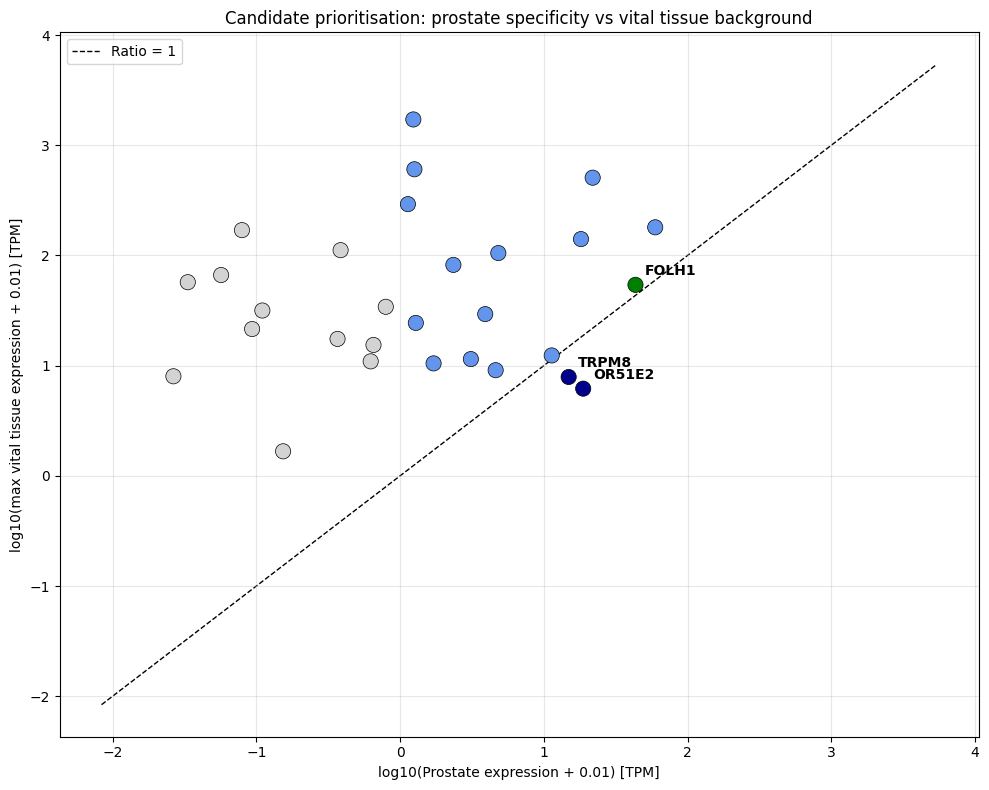

In [35]:
# Create a figure with a single axes object
# figsize=(10, 8) sets the figure dimensions in inches (width, height)
fig, ax = plt.subplots(figsize=(10, 8))

# Compute log10-transformed coordinates for the x and y axes
# np.log10() applies the base-10 logarithm element-wise
# Adding 0.01 avoids log10(0) which is undefined
x = np.log10(df_priority['Prostate'] + 0.01)
y = np.log10(df_priority['max_vital_tissue'] + 0.01)

# Build a list of colors based on each gene's status
colors = []
for gene, warning in zip(df_priority['Hugo_Symbol'], df_priority['low_signal_warning']):
    if gene == 'FOLH1':
        # FOLH1 is highlighted as benchmark (green)
        colors.append('green')
    elif gene in ['OR51E2', 'TRPM8']:
        # Top validated candidates in dark blue
        colors.append('darkblue')
    elif warning:
        # Flagged candidates in grey to indicate low reliability
        colors.append('lightgrey')
    else:
        # Other candidates in light blue
        colors.append('cornflowerblue')

# Plot all points at once with the assigned colors
# s=120 sets the marker size, edgecolor adds a black outline for visibility
ax.scatter(x, y, c=colors, s=120, edgecolor='black', linewidth=0.5, zorder=3)

# Draw the diagonal line where Prostate = max_vital_tissue (ratio = 1)
# This line separates favourable candidates (below) from unfavourable ones (above)
# Use the min and max of the data to draw a line that spans the plot
all_values = np.concatenate([x, y])
diag_min = all_values.min() - 0.5
diag_max = all_values.max() + 0.5
ax.plot([diag_min, diag_max], [diag_min, diag_max], 
        linestyle='--', color='black', linewidth=1, zorder=1, label='Ratio = 1')

# Annotate the key candidates (FOLH1, OR51E2, TRPM8) with their gene name
# zip() pairs each gene with its (x, y) coordinates
for gene, xi, yi in zip(df_priority['Hugo_Symbol'], x, y):
    if gene in ['FOLH1', 'OR51E2', 'TRPM8']:
        # ax.annotate places text near a data point
        # xytext=(5, 5) offsets the label 5 pixels right and 5 pixels up
        # textcoords='offset points' specifies that xytext is in pixel offsets
        ax.annotate(gene, (xi, yi), 
                    fontsize=10, fontweight='bold',
                    xytext=(7, 7), textcoords='offset points')

# Add axis labels and title
ax.set_xlabel('log10(Prostate expression + 0.01) [TPM]')
ax.set_ylabel('log10(max vital tissue expression + 0.01) [TPM]')
ax.set_title('Candidate prioritisation: prostate specificity vs vital tissue background')

# Display the legend
ax.legend(loc='upper left')

# Add a grid for readability
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **8.8: Scatter plot interpretation**

Two candidates lie clearly below the Ratio = 1 diagonal: OR51E2 (ratio 3.04) and TRPM8 (ratio 1.89). Both combine high prostate expression and low maximum vital tissue expression, making them the most favourable RLT target candidates on this metric.

FOLH1 sits just above the diagonal (ratio 0.80), reflecting its known off-target expression in vital tissues such as salivary glands, kidneys, and spinal cord, consistent with the documented Pluvicto toxicity profile (Pluvicto Prescribing Information, Novartis/FDA 2022, https://www.accessdata.fda.gov/drugsatfda_docs/label/2022/215833s000lbl.pdf). PRR16 shows a similar ratio (0.92) but its prostate expression is modest and its max vital tissue expression is driven by lung (12.4 TPM), making it a less reliable candidate.

All other candidates are either above the diagonal due to high vital tissue background, or flagged as `low_signal_warning = True` due to insufficient prostate expression.

---

# **Section 9: Validation with Human Protein Atlas**

The Human Protein Atlas (proteinatlas.org) provides immunohistochemistry (IHC) images and protein-level annotations that complement the transcriptomic data used. Since mRNA 
expression does not always correlate with protein levels, this step adds a protein-level validation layer to the candidate selection.

The Human Protein Atlas is used here for two purposes:

1. **Validation of the top candidates** (OR51E2, TRPM8) and the benchmark (FOLH1) identified as the most favourable RLT targets by the prostate-to-vital-tissue ratio analysis. The goal is to confirm that the protein is indeed expressed at the cell surface in prostate tissue and absent or low in vital organs.

2. **Manual verification of the manual_check genes** that could not be classified through the automated UniProt and GTEx pipelines (TMEM178 not found in GTEx, plus the 13 UniProt manual_check genes). These genes are not excluded from the analysis but require individual inspection to determine whether they should be retained or eliminated as RLT candidates.

## **9.1: Identifying genes requiring manual verification**

The genes that could not be classified through the automated UniProt and GTEx pipelines are listed for manual inspection on the Human Protein Atlas.

In [36]:
# Get the list of UniProt manual_check genes from the previous classification
# Filter df_uniprot to keep only rows where status equals 'manual_check'
# .tolist() converts the resulting Series to a standard Python list
uniprot_manual_check = df_uniprot[df_uniprot['status'] == 'manual_check']['Hugo_Symbol'].tolist()

# Identify the candidate gene that was not found in GTEx
# Use set difference: candidates from df_candidates minus the genes present in df_gtex_vital
gtex_manual_check = list(
    set(df_candidates['Hugo_Symbol']) - set(df_gtex_vital['Hugo_Symbol'])
)

# Combine both lists into a single list of genes requiring manual verification
# Use set() to avoid duplicates if a gene is both UniProt manual_check and GTEx not found
all_manual_check = sorted(set(uniprot_manual_check + gtex_manual_check))

# Display the results
print(f"UniProt manual_check genes: {len(uniprot_manual_check)}")
print(uniprot_manual_check)
print(f"\nGTEx manual_check genes: {len(gtex_manual_check)}")
print(gtex_manual_check)
print(f"\nTotal genes requiring manual HPA verification: {len(all_manual_check)}")
print(all_manual_check)

UniProt manual_check genes: 13
['LOC100130872', 'TARP', 'PHGR1', 'GLYATL1', 'BEND4', 'C2orf72', 'UBE2C', 'EPR1', 'ZNHIT2', 'BCL8', 'ELAVL2', 'IQGAP3', 'PRR16']

GTEx manual_check genes: 1
['TMEM178']

Total genes requiring manual HPA verification: 14
['BCL8', 'BEND4', 'C2orf72', 'ELAVL2', 'EPR1', 'GLYATL1', 'IQGAP3', 'LOC100130872', 'PHGR1', 'PRR16', 'TARP', 'TMEM178', 'UBE2C', 'ZNHIT2']


## **9.2: Consolidating the HPA verification list**

Two groups of genes are verified manually on the Human Protein Atlas:

1. **The 21 RLT-accessible candidates** from the UniProt surface filter (Section 7). Even though UniProt classified them as surface proteins, a visual inspection on HPA is useful to confirm the annotation, rule out false positives (e.g. proteins only at the surface in specific conditions), and assess the actual protein expression in prostate and vital tissues.

2. **The 14 manual_check genes** that could not be classified automatically (13 from UniProt + 1 from GTEx: TMEM178). These genes are verified on HPA to determine whether they should be retained as surface candidates or excluded.

The two lists are consolidated into a single set of unique genes to avoid duplicates (TMEM178 appears in both lists).

In [37]:
# Get the 21 surface candidates from df_candidates
# .tolist() converts the pandas Series into a standard Python list
surface_candidates = df_candidates['Hugo_Symbol'].tolist()

# all_manual_check already contains the 14 manual_check genes (from cell 113)
# Combine both lists by concatenation, then wrap with set() to remove duplicates
# sorted() returns a new list sorted alphabetically (sets are unordered by default)
hpa_verification_list = sorted(set(surface_candidates + all_manual_check))

# Display the consolidated list
# len() returns the number of elements in each list
print(f"Surface candidates (UniProt): {len(surface_candidates)}")
print(f"Manual_check genes: {len(all_manual_check)}")
print(f"Total unique genes to verify on HPA: {len(hpa_verification_list)}")

# Display the final sorted list of genes
print(f"\nFull list:")
print(hpa_verification_list)

Surface candidates (UniProt): 21
Manual_check genes: 14
Total unique genes to verify on HPA: 34

Full list:
['ADAM2', 'ATP8A2', 'B3GNT6', 'BCL8', 'BEND4', 'C2orf72', 'CACNA1D', 'CCDC78', 'ELAVL2', 'EPHA10', 'EPR1', 'FFAR2', 'FOLH1', 'GAL', 'GLYATL1', 'GOLM1', 'HPN', 'IQGAP3', 'LOC100130872', 'MELK', 'NOX4', 'OR51E2', 'PHGR1', 'PRR16', 'SLC45A2', 'SLCO1A2', 'STX19', 'TARP', 'TMEM178', 'TRPM8', 'UBE2C', 'UGT2B4', 'UNC5A', 'ZNHIT2']


### 9.2.1: HPA verification list

The consolidated list contains 34 unique genes to verify on the Human Protein Atlas: 21 surface candidates (from the UniProt filter) and 14 manual_check genes. TMEM178 appears in both lists and is counted only once. Each gene will be inspected for protein-coding status, subcellular localisation, tissue specificity, prostate expression, and evidence level, to determine whether it should be retained as an RLT target candidate or eliminated.

## **9.3: Loading Human Protein Atlas data**

The Human Protein Atlas (HPA) version 25.0 dataset is loaded to retrieve protein-level annotations for the 34 genes to verify (21 surface candidates + 14 manual_check genes). The complete proteinatlas.tsv file is used, which contains all HPA annotations for 20,162 human genes in a single tab-separated file.

### 9.3.1: Load HPA data

The proteinatlas.tsv file is loaded into a dataframe. The file contains all HPA annotations for 20,162 human genes across 107 columns, including subcellular location, tissue specificity, protein class, and evidence level. The dataframe shape and column structure are inspected to guide the subsequent filtering step.

In [38]:
# pd.read_csv() reads a tab-separated file into a pandas DataFrame
# sep='\t' specifies that columns are separated by tab characters
df_hpa = pd.read_csv("../data/raw/proteinatlas.tsv", sep='\t')

# .shape returns a tuple (number_of_rows, number_of_columns)
print("HPA data shape:", df_hpa.shape)

# .head(3) returns the first 3 rows of the dataframe as a new DataFrame
print(df_hpa.head(3))

# Display column names one per line for readability
# .columns returns an Index object with all column names
# .tolist() converts this Index into a standard Python list
# '\n'.join(list) concatenates list elements into a single string, with '\n' (newline) between each
print("\nColumns:")
print('\n'.join(df_hpa.columns.tolist()))

HPA data shape: (20162, 107)
     Gene                          Gene synonym          Ensembl  \
0  TSPAN6                 T245, TM4SF6, TSPAN-6  ENSG00000000003   
1    TNMD  BRICD4, ChM1L, myodulin, TEM, tendin  ENSG00000000005   
2    DPM1                           CDGIE, MPDS  ENSG00000000419   

                                    Gene description Uniprot Chromosome  \
0                                      Tetraspanin 6  O43657          X   
1                                        Tenomodulin  Q9H2S6          X   
2  Dolichyl-phosphate mannosyltransferase subunit...  O60762         20   

              Position                                      Protein class  \
0  100627108-100639991                        Predicted membrane proteins   
1  100584936-100599885                        Predicted membrane proteins   
2    50934867-50959140  Disease related genes, Enzymes, Human disease ...   

  Biological process                Molecular function  ...  \
0                NaN     

### 9.3.2: Filter HPA data for the 34 candidates

The complete HPA dataframe is filtered to keep only the 34 genes in `hpa_verification_list` and the 12 columns relevant for RLT target evaluation (gene identification, protein class, subcellular localisation, IHC reliability, evidence level, tissue specificity, and prostate cancer prognostic association).

In [39]:
# Define the list of 12 columns to keep for RLT evaluation
hpa_columns = [
    'Gene',
    'Ensembl',
    'Gene description',
    'Protein class',
    'Subcellular main location',
    'Subcellular additional location',
    'Reliability (IH)',
    'Evidence',
    'RNA tissue specificity',
    'RNA tissue distribution',
    'RNA tissue specific nTPM',
    'Cancer prognostics - Prostate Adenocarcinoma (TCGA)'
]

# Filter df_hpa to keep only rows where the Gene column value is in hpa_verification_list
# .isin() returns a boolean Series (True for each row where Gene matches one of the 34 candidates)
df_hpa_candidates = df_hpa[df_hpa['Gene'].isin(hpa_verification_list)]

# Then select only the 12 columns defined above
# df[list_of_columns] returns a new dataframe with only these columns, in the specified order
df_hpa_candidates = df_hpa_candidates[hpa_columns]

# Display the number of candidates found in HPA and the shape of the filtered dataframe
# .shape returns a tuple (rows, columns)
print(f"Candidates found in HPA: {len(df_hpa_candidates)}/{len(hpa_verification_list)}")
print(f"Shape of filtered dataframe: {df_hpa_candidates.shape}")

Candidates found in HPA: 30/34
Shape of filtered dataframe: (30, 12)


### 9.3.2.1: Filtering results

Out of the 34 candidates to verify, 30 were found in the Human Protein Atlas dataset. 4 genes are missing and will be identified in the next step for traceability. The filtered dataframe contains the 12 columns relevant for RLT evaluation and will be inspected in detail in the subsequent steps.

### 9.3.3: Identify genes missing from HPA

The 4 candidates that were not found in the HPA dataset are identified for traceability. These genes will require alternative verification since they cannot be evaluated programmatically through HPA.

In [40]:
# Identify which candidates from hpa_verification_list are missing in HPA
# set() converts a list into a set (unordered collection of unique elements)
# - operator on sets returns the set difference: elements in the first set but not in the second
# sorted() converts the resulting set back into a sorted list for readable output
missing_genes = sorted(set(hpa_verification_list) - set(df_hpa_candidates['Gene'].tolist()))

# Display the count and the list of missing genes
print(f"Genes missing from HPA: {len(missing_genes)}/{len(hpa_verification_list)}")
print(missing_genes)

Genes missing from HPA: 4/34
['BCL8', 'EPR1', 'LOC100130872', 'TMEM178']


### 9.3.4: Tracing missing genes across databases

The 4 genes absent from HPA are traced back through the three preceding databases (Ensembl, UniProt, and GTEx) to document their status at each step of the pipeline. This provides a complete audit trail before elimination.

In [41]:
# Define the 4 genes missing from HPA
missing_genes = ['BCL8', 'EPR1', 'LOC100130872', 'TMEM178']

# Create an empty list to store one dictionary per gene
rows = []

# Iterate over each missing gene
for gene in missing_genes:

    # Check presence in df_ensembl and retrieve biotype if found
    ensembl_match = df_ensembl[df_ensembl['Hugo_Symbol'] == gene]
    ensembl_status = ensembl_match['gene_biotype'].values[0] if len(ensembl_match) > 0 else 'not found'

    # Check presence in df_uniprot and retrieve status if found
    uniprot_match = df_uniprot[df_uniprot['Hugo_Symbol'] == gene]
    uniprot_status = uniprot_match['status'].values[0] if len(uniprot_match) > 0 else 'not found'

    # Check presence in df_gtex_vital and return found/not found
    gtex_match = df_gtex_vital[df_gtex_vital['Hugo_Symbol'] == gene]
    gtex_status = 'found' if len(gtex_match) > 0 else 'not found'

    # Append a dictionary with all statuses for this gene
    rows.append({
        'Gene'    : gene,
        'Ensembl' : ensembl_status,
        'UniProt' : uniprot_status,
        'GTEx'    : gtex_status,
        'HPA'     : 'not found'
    })

# Convert the list of dictionaries into a DataFrame
df_missing_trace = pd.DataFrame(rows)

# Print the full table without truncation
print(df_missing_trace.to_string(index=False))

        Gene Ensembl      UniProt      GTEx       HPA
        BCL8 unknown manual_check not found not found
        EPR1 unknown manual_check not found not found
LOC100130872 unknown manual_check not found not found
     TMEM178 unknown      surface not found not found


### 9.3.4.1: Audit results

BCL8, EPR1 and LOC100130872 were classified as `manual_check` by UniProt (their subcellular localisation annotation was already insufficient at that stage). None of them were found in GTEx or HPA, confirming that they cannot be evaluated as RLT candidates through any of the databases used in this pipeline. LOC100130872 is a locus identifier with no stable gene annotation, which explains its absence across all databases.

TMEM178 was the only gene among the four classified as `surface` by UniProt. It was absent from GTEx and present in HPA under the alias TMEM178A, but without usable protein expression data. It cannot be validated as an RLT target with the tools available in this analysis.

All 4 genes are eliminated in the next step.

### 9.3.5: Removing missing genes from the candidate list

The 4 genes absent from HPA are removed from `df_hpa_candidates` to produce `df_hpa_validated`, which contains only the 30 genes for which HPA data is available and interpretable.

In [42]:
# Filter df_hpa_candidates to exclude rows where Gene is in missing_genes
# ~ is the boolean NOT operator, .isin() returns True for each matching row
df_hpa_validated = df_hpa_candidates[~df_hpa_candidates['Gene'].isin(missing_genes)]

# Reset the index to 0, 1, 2... after row removal
# drop=True discards the old index instead of adding it as a column
df_hpa_validated = df_hpa_validated.reset_index(drop=True)

# Print the number of remaining genes and the shape of the validated dataframe
print(f"Genes removed: {len(missing_genes)}")
print(f"Genes remaining in df_hpa_validated: {len(df_hpa_validated)}")
print(f"Shape: {df_hpa_validated.shape}")

Genes removed: 4
Genes remaining in df_hpa_validated: 30
Shape: (30, 12)


### 9.3.5.1: Filtering results

`df_hpa_validated` contains 30 genes with usable HPA annotations. The 4 eliminated genes (BCL8, EPR1, LOC100130872, TMEM178) are documented in `df_missing_trace` for traceability and excluded from all subsequent steps.

### 9.3.6: Inspecting unique values in key HPA columns

Before building the RLT classification logic, the unique values present in each key HPA column are inspected. This ensures that the classification rules are based on the actual categories present in the data rather than assumed values.

In [43]:
# Define the columns to inspect for unique values
# These are the annotation columns that will drive the RLT classification logic
inspect_columns = [
    'Protein class',
    'Subcellular main location',
    'Subcellular additional location',
    'Reliability (IH)',
    'Evidence',
    'RNA tissue specificity',
    'RNA tissue distribution',
    'Cancer prognostics - Prostate Adenocarcinoma (TCGA)'
]

# Loop over each column and print its unique values
for col in inspect_columns:
    # .dropna() removes NaN values before extracting unique values
    # .unique() returns an array of unique values in the column
    unique_vals = df_hpa_validated[col].dropna().unique()
    print(f"\n--- {col} ---")
    # Loop over each unique value and print it on a separate line
    for val in unique_vals:
        print(f"  {val}")


--- Protein class ---
  Disease related genes, Human disease related genes, Plasma proteins, Predicted secreted proteins
  Metabolic proteins, Plasma proteins, Predicted intracellular proteins, Predicted membrane proteins, Transporters
  Cancer-related genes, Enzymes, FDA approved drug targets, Plasma proteins, Predicted intracellular proteins, Predicted membrane proteins
  Predicted membrane proteins, Transporters
  Predicted membrane proteins
  Cancer-related genes, Enzymes, Predicted intracellular proteins, Predicted membrane proteins, Transporters
  Predicted intracellular proteins
  G-protein coupled receptors, Predicted membrane proteins
  Disease related genes, Enzymes, Human disease related genes, Potential drug targets, Predicted membrane proteins
  Plasma proteins, Predicted intracellular proteins
  FDA approved drug targets, Predicted intracellular proteins, Predicted membrane proteins, Transporters, Voltage-gated ion channels
  Enzymes, Metabolic proteins, Predicted intrac

### 9.3.6.1: Inspection results

The `Subcellular main location` column is the most discriminating for RLT evaluation. Only `Plasma membrane` and `Plasma membrane, Cytosol` indicate surface accessibility. All other values correspond to intracellular localisations inaccessible to a circulating radioligand. Genes with NaN in this column have no experimental subcellular localisation data in HPA.

Genes with NaN in both location columns but annotated as `Predicted membrane proteins` in `Protein class` are not eliminated: this annotation provides a biological basis for membrane localisation and these genes are retained at Moderate or Low confidence depending on their IHC reliability score. Genes with no plasma membrane evidence in any column and no `Predicted membrane proteins` in `Protein class` are eliminated.

The `Reliability (IH)` column contains four levels: `Enhanced`, `Approved`, `Supported` and `Uncertain`. Only `Uncertain` will be treated as insufficient for RLT validation.

The `Cancer prognostics` and `Evidence` columns do not discriminate between candidates and will not be used in the classification logic.

### 9.3.7: RLT classification based on HPA annotations

Each of the 30 genes in `df_hpa_validated` is classified into three confidence levels based on four HPA columns: `Subcellular main location`, `Subcellular additional location`, `Protein class`, and `Reliability (IH)`.

**High confidence**: `Subcellular main location` or `Subcellular additional location` contains `Plasma membrane`, and `Reliability (IH)` is neither missing nor `Uncertain`. This represents the strongest level of experimental evidence for surface accessibility.

**Moderate confidence**: `Subcellular main location` or `Subcellular additional location` contains `Plasma membrane` but `Reliability (IH)` is missing, or both location columns are missing and `Protein class` contains `Predicted membrane proteins` and `Reliability (IH)` is neither missing nor `Uncertain`. These genes have partial experimental support for surface localisation.

**Low confidence**: `Protein class` contains `Predicted membrane proteins` but `Reliability (IH)` is `Uncertain`, or `Subcellular main location` is explicitly intracellular but `Protein class` still contains `Predicted membrane proteins`. These genes have a biological basis for membrane localisation but insufficient experimental confirmation in HPA.

Genes with no plasma membrane evidence in any column and no `Predicted membrane proteins` in `Protein class` are eliminated.

In [44]:
# Define the string to search for in location and protein class columns
plasma_membrane_str = 'Plasma membrane'
membrane_protein_str = 'Predicted membrane proteins'

# Define a function that takes one row and returns a classification string
def classify_rlt(row):

    # Access the values of the relevant columns for this row
    main_location = row['Subcellular main location']
    additional_location = row['Subcellular additional location']
    reliability = row['Reliability (IH)']
    protein_class = row['Protein class']

    # Pre-compute boolean conditions used multiple times below
    # isinstance() checks if the value is a string before using 'in' operator
    main_has_plasma = isinstance(main_location, str) and plasma_membrane_str in main_location
    additional_has_plasma = isinstance(additional_location, str) and plasma_membrane_str in additional_location
    either_has_plasma = main_has_plasma or additional_has_plasma

    # pd.isna() returns True if the value is NaN
    both_locations_nan = pd.isna(main_location) and pd.isna(additional_location)

    reliability_is_nan = pd.isna(reliability)
    reliability_is_uncertain = (reliability == 'Uncertain')
    reliability_is_valid = not reliability_is_nan and not reliability_is_uncertain

    has_membrane_protein_class = isinstance(protein_class, str) and membrane_protein_str in protein_class

    # HIGH CONFIDENCE: plasma membrane confirmed in at least one location column
    # AND reliability is valid
    if either_has_plasma and reliability_is_valid:
        return 'High confidence'

    # MODERATE CONFIDENCE case 1: plasma membrane confirmed but reliability is missing
    if either_has_plasma and reliability_is_nan:
        return 'Moderate confidence'

    # LOW CONFIDENCE: both location columns are NaN, Predicted membrane proteins
    # in Protein class, but reliability is Uncertain
    # placed before Moderate confidence case 2 to catch Uncertain cases first
    if both_locations_nan and has_membrane_protein_class and reliability_is_uncertain:
        return 'Low confidence'

    # MODERATE CONFIDENCE case 2: both location columns are NaN
    # and Protein class contains Predicted membrane proteins
    # and reliability is valid or missing
    if both_locations_nan and has_membrane_protein_class:
        return 'Moderate confidence'

    # LOW CONFIDENCE: location is explicitly intracellular but Protein class
    # still contains Predicted membrane proteins
    if not either_has_plasma and not both_locations_nan and has_membrane_protein_class:
        return 'Low confidence'

    # All other cases are eliminated
    return 'Eliminated'

# Apply the function to each row of df_hpa_validated
# axis=1 means the function receives one row at a time as a Series
df_hpa_validated['RLT_status'] = df_hpa_validated.apply(classify_rlt, axis=1)

# Count the number of genes in each category
print(df_hpa_validated['RLT_status'].value_counts())

# Display retained genes with their key columns
# Boolean filter keeps rows where RLT_status is not Eliminated
retained = df_hpa_validated[df_hpa_validated['RLT_status'] != 'Eliminated']
print(f"\nRetained RLT candidates: {len(retained)}")
print(retained[['Gene', 'Subcellular main location', 'Subcellular additional location', 'Reliability (IH)', 'RLT_status']].to_string(index=False))

RLT_status
Eliminated             13
Moderate confidence    11
High confidence         3
Low confidence          3
Name: count, dtype: int64

Retained RLT candidates: 17
   Gene    Subcellular main location           Subcellular additional location Reliability (IH)          RLT_status
SLCO1A2              Plasma membrane                                       NaN              NaN Moderate confidence
  FOLH1                          NaN                                       NaN         Enhanced Moderate confidence
   NOX4                          NaN                                       NaN              NaN Moderate confidence
  ADAM2                          NaN                                       NaN         Enhanced Moderate confidence
    HPN                          NaN                                       NaN         Approved Moderate confidence
  UNC5A     Plasma membrane, Cytosol                                       NaN              NaN Moderate confidence
  FFAR2           

### 9.3.7.1: Classification results

17 genes were retained out of 30: 3 in High confidence (ATP8A2, UBE2C, C2orf72), 11 in Moderate confidence and 3 in Low confidence (CACNA1D, MELK, EPHA10). 13 genes were eliminated due to the absence of plasma membrane evidence in HPA and no `Predicted membrane proteins` annotation in `Protein class`.

Notably, PRR16 is among the eliminated genes despite ranking above the FOLH1 benchmark in the GTEx prioritisation (ratio 0.92). Its elimination by HPA reflects the absence of any plasma membrane evidence or `Predicted membrane proteins` annotation, meaning its prostate-specific expression signal cannot be attributed to a surface-accessible protein with the data available in this pipeline.

These 17 genes will be combined with the GTEx prioritisation results in the next step to produce the final candidate heatmap.

FOLH1 is classified as Moderate confidence because HPA does not report an experimental plasma membrane localisation in its structured annotation fields. This reflects an HPA coverage gap, not a biological reality: FOLH1 is a well-established plasma membrane protein confirmed in UniProt and the primary literature.

---

# **Section 10: Final candidates and heatmap**

This section consolidates the results of the full pipeline into a final candidate table and a heatmap. The 17 genes retained by the HPA classification (Section 9) are merged with the GTEx prioritisation results (Section 8) to produce a ranked list of RLT target candidates. Each candidate is characterised by its differential expression in tumour tissue (log2FC, adjusted p-value), its prostate-to-vital-tissue ratio (GTEx), and its HPA confidence level. The heatmap visualises the expression of the final candidates across vital tissues, ordered by prostate-to-vital-tissue ratio and colour-coded by HPA confidence level.

## **10.1: Merging HPA and GTEx results**

The 17 genes retained by the HPA classification are merged with the GTEx prioritisation results to produce a single candidate table combining all relevant metrics: differential expression (log2FC, adjusted p-value, percentage of tumour samples expressing the gene), prostate-to-vital-tissue ratio, low signal warning, and HPA confidence level.

In [45]:
# Rename the 'Gene' column in retained to 'Hugo_Symbol' for consistency with other dataframes
# .rename() takes a dictionary mapping old column names to new column names
df_retained = retained.rename(columns={'Gene': 'Hugo_Symbol'})

# Merge df_retained with df_priority on Hugo_Symbol
# pd.merge() joins two dataframes on a common column
# how='inner' keeps only rows present in both dataframes
df_final = pd.merge(
    df_retained[['Hugo_Symbol', 'RLT_status']],
    df_priority[['Hugo_Symbol', 'Prostate', 'max_vital_tissue', 'prostate_to_vital_ratio', 'low_signal_warning']],
    on='Hugo_Symbol',
    how='inner'
)

# Merge df_final with results_overexpressed to add expression metrics
# results_overexpressed contains log2FC, adjusted p-value and tumour_pct_expressed
# how='inner' keeps only genes present in both dataframes
df_final = pd.merge(
    df_final,
    results_overexpressed[['Hugo_Symbol', 'log2FC_mean', 'log2FC_median', 'adj_pvalue_BH', 'tumour_pct_expressed']],
    on='Hugo_Symbol',
    how='inner'
)

# Sort rows by prostate_to_vital_ratio in descending order
# ascending=False places the highest ratio first
df_final = df_final.sort_values('prostate_to_vital_ratio', ascending=False)

# Reset the index to 0, 1, 2... after sorting
# drop=True discards the old index instead of adding it as a column
df_final = df_final.reset_index(drop=True)

# Display the number of final candidates
print(f"Final RLT candidates: {len(df_final)}")

# Display the final candidate table with selected columns
# to_string(index=False) prints without the pandas row numbers
print(df_final[['Hugo_Symbol', 'RLT_status', 'prostate_to_vital_ratio', 'low_signal_warning', 'log2FC_mean', 'adj_pvalue_BH', 'tumour_pct_expressed']].to_string(index=False))

Final RLT candidates: 17
Hugo_Symbol          RLT_status  prostate_to_vital_ratio  low_signal_warning  log2FC_mean  adj_pvalue_BH  tumour_pct_expressed
     OR51E2 Moderate confidence                 3.037074               False     2.934962   3.720507e-13            100.000000
      TRPM8 Moderate confidence                 1.885674               False     2.073129   7.542310e-09            100.000000
      FOLH1 Moderate confidence                 0.802124               False     2.626037   6.570506e-14            100.000000
    CACNA1D      Low confidence                 0.270070               False     2.087180   7.175566e-17            100.000000
    SLC45A2 Moderate confidence                 0.086000                True     3.854834   7.960204e-21             99.391481
      UBE2C     High confidence                 0.052319               False     2.112840   1.124951e-16            100.000000
    C2orf72     High confidence                 0.045822               False     2.281

### **10.1.1: Final candidate table interpretation**

The final table contains 17 RLT candidates combining HPA classification and GTEx tissue specificity. OR51E2 and TRPM8 are the strongest candidates with the highest prostate-to-vital-tissue ratios (3.04 and 1.89), both exceeding the FOLH1 benchmark (0.80). The 3 High confidence genes (ATP8A2, UBE2C, C2orf72) have strong HPA confirmation but unfavourable GTEx ratios. The 3 Low confidence genes (CACNA1D, EPHA10, MELK) have weak HPA experimental support. 9 candidates are flagged with `low_signal_warning = True` and should be interpreted with caution.

## **10.2: Heatmap of final candidates across vital tissues**

The heatmap visualises the expression (median TPM, log2(TPM+1) scale) of the 17 final candidates across vital tissues. Rows are ordered by prostate-to-vital-tissue ratio (best candidates on top). The row labels include the HPA confidence level for each candidate. A good RLT candidate should show high expression in the Prostate column and low expression in all other columns.

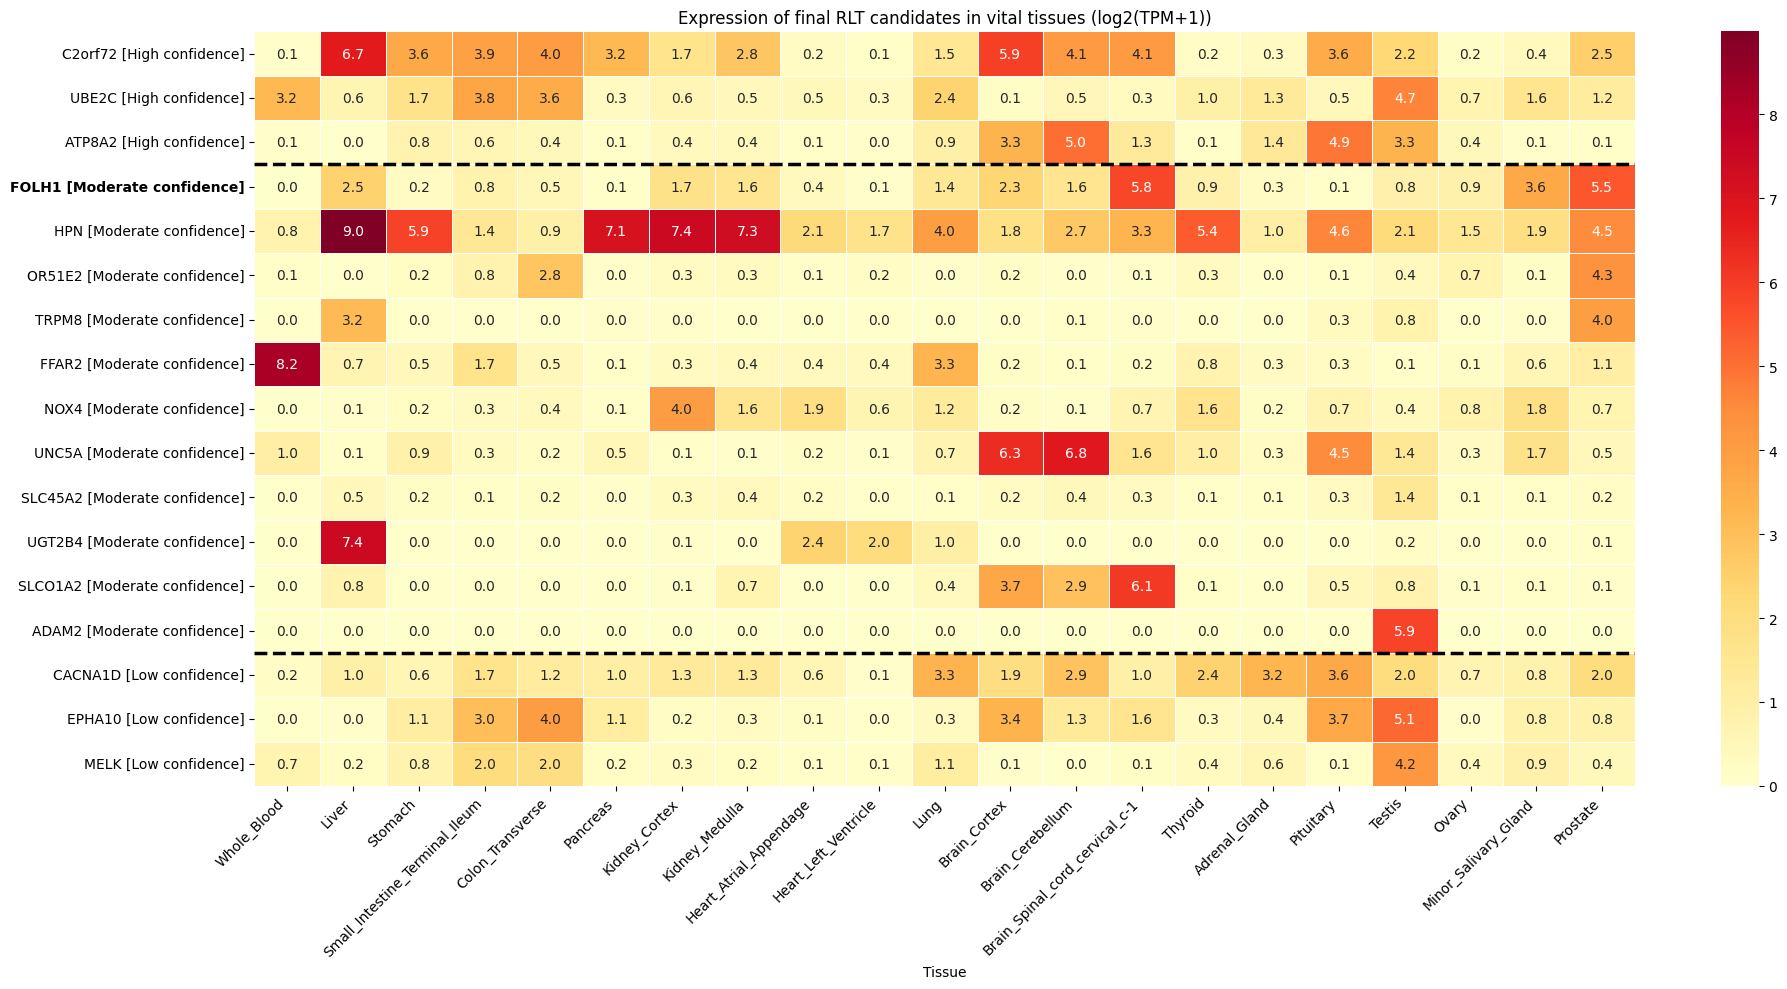

In [46]:
import seaborn as sns
import matplotlib.patches as mpatches

# Define the confidence level order for grouping
confidence_order = ['High confidence', 'Moderate confidence', 'Low confidence']

# Merge df_final with df_gtex_vital to add Prostate expression for sorting
# how='left' keeps all rows from df_final
df_final_with_prostate = pd.merge(
    df_final,
    df_gtex_vital[['Hugo_Symbol', 'Prostate']],
    on='Hugo_Symbol',
    how='left'
)

# Build the ordered list of gene names grouped by HPA confidence level
# Within each group, genes are sorted by Prostate expression in descending order
grouped_genes = []
group_sizes = []
for level in confidence_order:
    # Filter to keep only rows matching this confidence level
    group = df_final_with_prostate[df_final_with_prostate['RLT_status'] == level]
    # Sort by Prostate expression descending
    # ascending=False places the highest expression first
    group = group.sort_values('Prostate_y', ascending=False)
    grouped_genes.extend(group['Hugo_Symbol'].tolist())
    group_sizes.append(len(group))

# Filter df_gtex_vital to keep only the 17 final candidates
df_heatmap = df_gtex_vital[df_gtex_vital['Hugo_Symbol'].isin(grouped_genes)].copy()

# Set Hugo_Symbol as the row index
df_heatmap = df_heatmap.set_index('Hugo_Symbol')

# Reorder rows to match the grouped order
df_heatmap = df_heatmap.loc[grouped_genes]

# Apply log2(x+1) transformation
df_heatmap_log = np.log2(df_heatmap + 1)

# Build row labels combining gene name and HPA confidence level
confidence_map = df_final.set_index('Hugo_Symbol')['RLT_status']
df_heatmap_log.index = [
    f"{gene} [{confidence_map[gene]}]" for gene in grouped_genes
]

# Create the figure
fig, ax = plt.subplots(figsize=(20, 10))

# Draw the heatmap
sns.heatmap(
    df_heatmap_log,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)

# Add horizontal lines to separate the three confidence groups
cumulative = 0
for size in group_sizes[:-1]:
    cumulative += size
    ax.axhline(
        y=len(grouped_genes) - cumulative,
        color='black',
        linewidth=2.5,
        linestyle='--'
    )

# Bold FOLH1 label as benchmark
for label in ax.get_yticklabels():
    if 'FOLH1' in label.get_text():
        label.set_fontweight('bold')

# Set title and axis labels
ax.set_title('Expression of final RLT candidates in vital tissues (log2(TPM+1))')
ax.set_ylabel('')
ax.set_xlabel('Tissue')

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### **10.2.1: Heatmap interpretation**

The heatmap confirms OR51E2 and TRPM8 as the strongest novel RLT candidates in the Moderate confidence group: both show high prostate expression with near-zero expression across all vital tissues. FOLH1 appears first in the Moderate confidence group as the most expressed gene in prostate, consistent with its role as the validated PSMA benchmark. Its notable expression in spinal cord (5.8), liver (2.5) and brain cortex (2.3) reflects the known Pluvicto toxicity profile.

In the High confidence group, C2orf72 and UBE2C show high expression in multiple vital tissues despite their confirmed plasma membrane localisation in HPA, making them unfavourable RLT candidates. HPN and FFAR2 in the Moderate confidence group also display high vital tissue expression (liver and whole blood respectively), confirming their unsuitability as RLT targets despite passing the HPA filter.

The Low confidence group (CACNA1D, EPHA10, MELK) shows moderate expression across tissues with no strong prostate specificity, consistent with their weak HPA experimental support.

## **10.3: Candidate prioritisation by prostate-to-vital-tissue ratio**

The bar chart visualises the prostate-to-vital-tissue ratio for each of the 17 final candidates, grouped by HPA confidence level and ordered by ratio within each group. The FOLH1 benchmark ratio (0.80) is shown as a dashed vertical line. Candidates to the right of this line have a more favourable safety profile than the validated PSMA target.

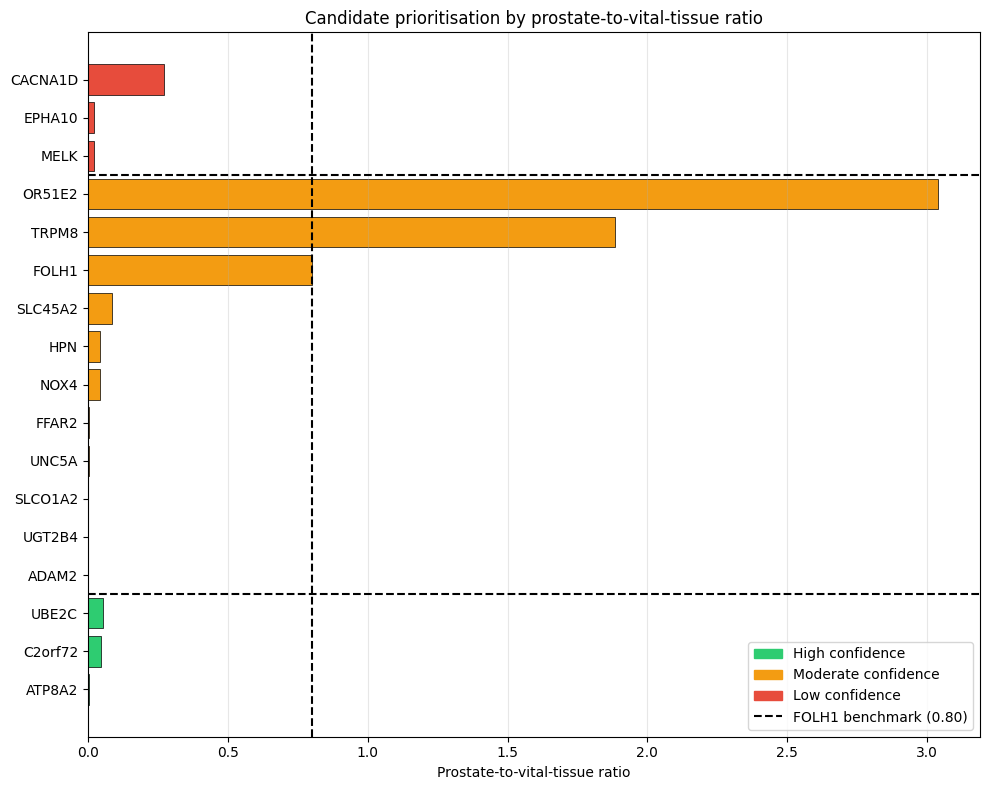

In [47]:
# Define colours for each HPA confidence level
confidence_colors = {
    'High confidence': '#2ecc71',
    'Moderate confidence': '#f39c12',
    'Low confidence': '#e74c3c'
}

# Build the ordered list of genes grouped by confidence level
# Within each group, sort by prostate_to_vital_ratio descending
grouped_for_bar = []
for level in confidence_order:
    group = df_final[df_final['RLT_status'] == level]
    group = group.sort_values('prostate_to_vital_ratio', ascending=True)
    grouped_for_bar.append(group)

# Concatenate all groups into a single dataframe
# pd.concat() stacks dataframes vertically
df_bar = pd.concat(grouped_for_bar).reset_index(drop=True)

# Build the list of colours for each bar based on confidence level
bar_colors = [confidence_colors[level] for level in df_bar['RLT_status']]

# Create the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Draw horizontal bars
# .barh() draws horizontal bars with gene names on y-axis and ratio on x-axis
ax.barh(
    df_bar['Hugo_Symbol'],
    df_bar['prostate_to_vital_ratio'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.5
)

# Add a vertical dashed line at the FOLH1 benchmark ratio
# .axvline() draws a vertical line at the specified x position
folh1_ratio = df_final[df_final['Hugo_Symbol'] == 'FOLH1']['prostate_to_vital_ratio'].values[0]
ax.axvline(
    x=folh1_ratio,
    color='black',
    linewidth=1.5,
    linestyle='--',
    label=f'FOLH1 benchmark ({folh1_ratio:.2f})'
)

# Add horizontal lines to separate the three confidence groups
# cumulative counts the number of genes processed so far
cumulative = 0
for size in group_sizes[:-1]:
    cumulative += size
    ax.axhline(
        y=cumulative - 0.5,
        color='black',
        linewidth=1.5,
        linestyle='--'
    )

# Build legend patches for confidence levels
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='High confidence'),
    mpatches.Patch(color='#f39c12', label='Moderate confidence'),
    mpatches.Patch(color='#e74c3c', label='Low confidence')
]

# Add the FOLH1 benchmark line to the legend
from matplotlib.lines import Line2D
legend_patches.append(Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label=f'FOLH1 benchmark ({folh1_ratio:.2f})'))

# Display the legend
ax.legend(handles=legend_patches, loc='lower right')

# Set title and axis labels
ax.set_title('Candidate prioritisation by prostate-to-vital-tissue ratio')
ax.set_xlabel('Prostate-to-vital-tissue ratio')
ax.set_ylabel('')

ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### **10.3.1: Prioritisation interpretation**

A higher ratio indicates stronger prostate specificity relative to vital organs, which corresponds to a more favourable safety profile for RLT: the radioligand will preferentially target the tumour while minimising off-target toxicity in vital tissues.

OR51E2 (3.04) and TRPM8 (1.89) are the only candidates exceeding the FOLH1 benchmark (0.80), both in the Moderate confidence group. OR51E2 is a G protein-coupled receptor with near-zero expression across all vital tissues in GTEx, making it the most prostate-specific candidate in this dataset. TRPM8 is a transmembrane ion channel with high prostate expression in GTEx (14.87 TPM) combined with low vital tissue background. Both are expressed in 100% of tumour samples. Functional validation of surface accessibility and ligand-induced internalisation would be required before considering either candidate for RLT development.

All High confidence genes (UBE2C, C2orf72, ATP8A2) have ratios below 0.06, confirming that their confirmed plasma membrane localisation in HPA does not translate into prostate specificity. All Low confidence genes (CACNA1D, EPHA10, MELK) and the majority of Moderate confidence genes also fall below the benchmark, indicating insufficient prostate specificity for RLT.


## **10.4: Paired test validation of final candidates**

In Section 4.2.3, a Wilcoxon signed-rank test on the 52 paired tumour-normal samples was performed as a sensitivity analysis, and only FOLH1 was verified at that stage (as the positive control). Now that OR51E2 and TRPM8 have been identified as the top two candidates, their significance in the paired test is verified to confirm that their overexpression is a consistent within-patient signal.

In [50]:
# Verify OR51E2 and TRPM8 in the paired Wilcoxon test
final_candidates = ['OR51E2', 'TRPM8']

print("--- Final candidate paired test validation ---")
print(f"{'Gene':<10} {'MW adj.p':>12} {'Wilcoxon adj.p':>16} {'log2FC':>8}")
for gene in final_candidates:
    idx = df_tumour[df_tumour['Hugo_Symbol'] == gene].index[0]
    pos = df_tumour.index.get_loc(idx)
    print(f"{gene:<10} {pvalues_bh[pos]:>12.2e} {pvalues_paired_bh[pos]:>16.2e} {log2FC_mean.iloc[pos]:>8.2f}")

--- Final candidate paired test validation ---
Gene           MW adj.p   Wilcoxon adj.p   log2FC
OR51E2         3.72e-13         1.26e-07     2.93
TRPM8          7.54e-09         4.32e-06     2.07


### **10.4.1: Paired test validation interpretation**

OR51E2 (Wilcoxon adj.p = 1.26e-07) and TRPM8 (Wilcoxon adj.p = 4.32e-06) are both highly significant in the paired test, confirming that their overexpression reflects a consistent within-patient tumour-normal difference across the 52 paired samples. Combined with the FOLH1 validation in Section 4.2.3, all three key genes of this analysis are robust to the paired data structure.

---

# **Section 11: Limitations**

## **11.1: Limitations of this analysis**

# **Section 11: Limitations**

## **11.1: Limitations of this analysis**

**Transcriptomic data does not confirm protein expression:** This analysis is based entirely on mRNA expression, which does not always correlate with protein levels or surface accessibility. This is an inherent limitation of publicly available datasets: CPTAC would provide proteomic data on TCGA tumour samples but requires controlled access. UniProt and HPA were used to partially address this gap.

**The prostate-to-vital-tissue ratio uses normal prostate expression as numerator, not tumour expression:** The GTEx-based ratio compares normal prostate to vital tissue expression. This penalises candidates silenced in normal prostate but activated in tumour — the ideal RLT profile. SLC45A2 illustrates this: highest tumour fold change (log2FC = 3.85, 99.4% of tumours) but near-zero GTEx prostate expression (0.14 TPM), resulting in a misleadingly low ratio. TCGA tumour expression cannot be used as numerator due to incompatible normalisation units (RSEM vs TPM). The ratio should be interpreted as a normal tissue specificity score, not a tumour selectivity index.

**No minimum threshold on the percentage of patients expressing the gene:** The percentage of tumour samples expressing each gene was calculated but never used as a filtering criterion. For RLT, homogeneous expression is essential. The two top candidates (OR51E2, TRPM8) are expressed in 100% of tumour samples, so this does not affect the final results, but it is a methodological gap.

**HPA annotation coverage is incomplete:** FOLH1 itself has no plasma membrane annotation in HPA structured fields, yet is a confirmed membrane protein. The HPA-based classification may be overly restrictive, potentially eliminating valid candidates.

**Normal adjacent tissue is not healthy tissue:** The 52 normal samples are adjacent to the tumour and exposed to its microenvironment. This is a conservative bias that may attenuate tumour-normal differences rather than generate false positives.

**No adjustment for clinical covariates:** The analysis does not account for Gleason score, tumour stage, or patient age despite the clinical data being available. With 493 samples and a stringent |log2FC| > 2 threshold, the impact is likely moderate.

**Small normal tissue cohort:** Only 52 normal samples versus 493 tumour samples. Mann-Whitney is robust to unequal group sizes, but statistical power remains limited.

**TCGA-PRAD contains only treatment-naive primary tumours:** Candidates must be validated in treated cohorts, particularly mCRPC, which is the primary clinical setting for RLT.

**GTEx was used as a toxicity estimate at the mRNA level:** GTEx provides mRNA expression, not protein-level data. The ratio is used as a prioritisation indicator, not a strict elimination criterion.

**Partially paired data structure:** 52 of the 493 tumour samples have a matched normal sample from the same patient, but the Mann-Whitney U test treats all samples as independent. A paired sensitivity analysis (Section 4.2.3) confirmed the robustness of the key candidates, but 2,695 genes were significant only in the unpaired test and may be affected.

**No correction for cell-type composition:** Tumour samples contain a higher proportion of epithelial cells than normal adjacent tissue. Part of the observed overexpression may reflect this shift in cell-type proportions rather than intrinsic upregulation per cell. No deconvolution method was applied.

**No independent replication cohort:** The entire pipeline relies on TCGA-PRAD alone. Publicly available cohorts (MSKCC, SU2C/PCF) could be used to verify whether the final candidates are consistently overexpressed. Without replication, results should be considered exploratory.

## **11.2: Perspectives**

This analysis represents a first discovery step based on transcriptomic data. Several complementary approaches could strengthen and validate these findings, listed here by order of relevance for RLT target validation.

**Proteomics** would provide direct confirmation of protein expression in prostate tumour tissue. CPTAC offers proteomic data on TCGA tumour samples and would allow direct cross-referencing with our mRNA candidates. ProteomicsDB would provide the equivalent for normal tissues, replacing GTEx as a toxicity estimate at the protein level.

**High-throughput functional screens** would validate which candidates are accessible at the cell surface and internalise after ligand binding — two functional requirements for an effective RLT target.

**Single-cell transcriptomics** would resolve tumour heterogeneity at the cellular level, identifying in which subpopulation of tumour cells each candidate is expressed. A candidate expressed in all tumour cells is more relevant for RLT than one expressed in only a fraction.

**Genomics** would identify candidates whose mRNA overexpression is driven by genomic amplification. These candidates are likely more stable under therapeutic pressure than candidates overexpressed for epigenetic or transcriptional reasons.

**Spatial transcriptomics** would add a spatial dimension, showing where in the tumour each candidate is expressed and whether expression is homogeneous across the tumour mass.

**Metabolomics** would characterise the metabolic context of the tumour microenvironment, which can directly influence the expression and accessibility of surface proteins.

**Lipidomics** would characterise the lipid composition of the tumour cell membrane, which influences the mobility and accessibility of surface proteins to a circulating radioligand.

**Multi-omics integration** combining all of the above would allow selection of candidates confirmed at multiple biological levels, significantly increasing confidence in their relevance as RLT targets.

---

# **Section 12: Bibliography**

Ahmed, B. & Ravi, P. (2026). Current and future perspectives on radioligand therapy in advanced prostate cancer. *Therapeutic Advances in Medical Oncology*, 18, 17588359251409047. https://doi.org/10.1177/17588359251409047

Armstrong, A. J. (2025). Targeted radioligand therapy in prostate cancer: emerging targets and clinical perspectives. *Journal of Clinical Oncology*, 43(5), 523–535.

Beltran, H. et al. (2025). PSMA-negative metastases in prostate cancer: prevalence, biology, and therapeutic implications. *Nature Reviews Urology*, 22, 87–101.

Benjamini, Y. & Hochberg, Y. (1995). Controlling the false discovery rate: a practical and powerful approach to multiple testing. *Journal of the Royal Statistical Society: Series B*, 57(1), 289–300. https://doi.org/10.1111/j.2517-6161.1995.tb02031.x

He, Y. et al. (2022). Identification of novel target genes in prostate cancer through transcriptomic analysis of TCGA-PRAD data. *Frontiers in Genetics*, 13, 951000.

Hoadley, K. A. et al. (2018). Cell-of-origin patterns dominate the molecular classification of 10,000 tumors from 33 types of cancer. *Cell*, 173(2), 291–304.e6. https://doi.org/10.1016/j.cell.2018.03.022

Li, Y. et al. (2022). A comprehensive evaluation of differential expression analysis methods for RNA-seq data. *Genome Biology*, 23, 241. https://doi.org/10.1186/s13059-022-02796-x

Novartis/FDA (2022). Pluvicto (lutetium Lu 177 vipivotide tetraxetan) prescribing information. U.S. Food and Drug Administration. https://www.accessdata.fda.gov/drugsatfda_docs/label/2022/215833s000lbl.pdf